In [16]:
!pip install stream-unzip
!pip install tqdm
import os
import json
import httpx
from stream_unzip import stream_unzip
from tqdm.auto import tqdm

SKIP THE BELOW CELL I UPLOADED THE MODIFIED DATASET

In [17]:
import json

filename = "WorldTrace_20k.jsonl"

def get_data_by_index(indx: int):
    with open(filename, 'r') as f:
        for i, line in enumerate(f):
            if i == indx:
                return json.loads(line)
    print("Not found the index ")
    return None

In [18]:
print(get_data_by_index(1).keys())


dict_keys(['Filename', 'Uploaded', 'Points', 'Start coordinate', 'Owner', 'Description', 'Tags', 'Visibility', 'Distance', 'Time', 'geometry', 'RunnerType', 'PaceMinPerKm', 'OriginalTime', 'Terrain', 'TerrainDifficulty'])


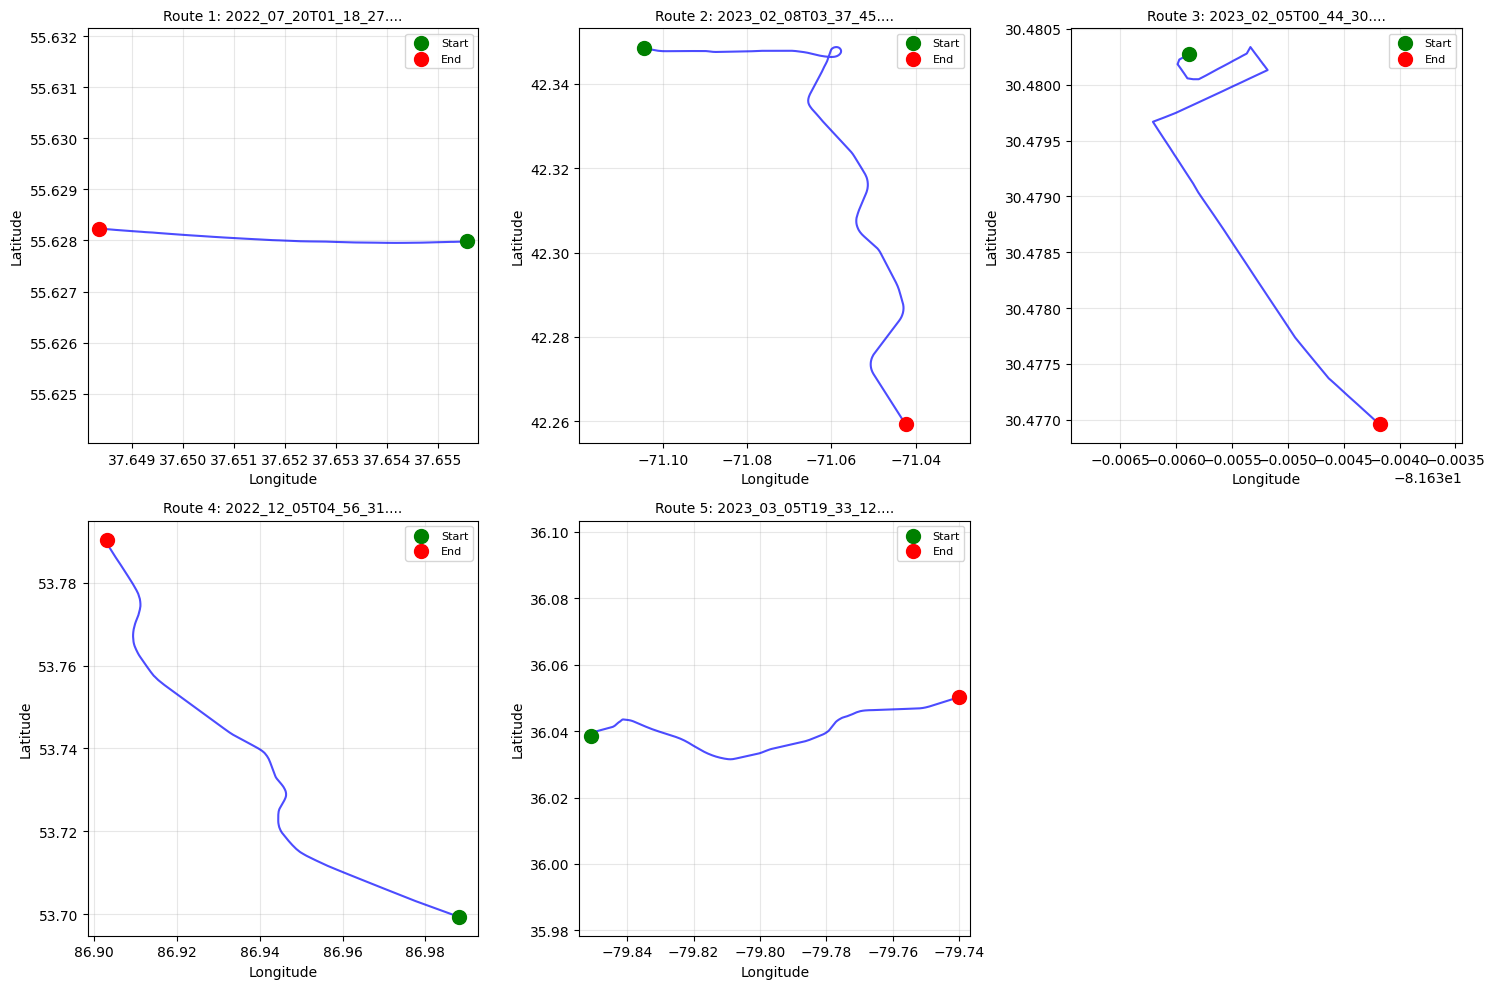


📍 Route Details:

1. 2022_07_20T01_18_27.591242Z.gpx
   Distance: 455.6308553917523m
   Duration: 178s
   Points: 74

2. 2023_02_08T03_37_45.045645Z.gpx
   Distance: 15028.128753511506m
   Duration: 4802s
   Points: 912

3. 2023_02_05T00_44_30.794945Z.gpx
   Distance: 564.1129088028989m
   Duration: 182s
   Points: 83

4. 2022_12_05T04_56_31.317111Z.gpx
   Distance: 12467.653081915985m
   Duration: 4767s
   Points: 562

5. 2023_03_05T19_33_12.870908Z.gpx
   Distance: 11085.979230037105m
   Duration: 3940s
   Points: 707



In [19]:
import json
import matplotlib.pyplot as plt

# Get first 5 routes using get_data_by_index
routes = []
for i in range(5):
    route = get_data_by_index(i)
    if route:
        routes.append(route)

# Plot all 5 routes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, route in enumerate(routes):
    ax = axes[idx]
    
    geometry = route.get('geometry', [])
    if geometry:
        lons = [point[0] for point in geometry]
        lats = [point[1] for point in geometry]
        
        ax.plot(lons, lats, 'b-', linewidth=1.5, alpha=0.7)
        ax.scatter(lons[0], lats[0], color='green', s=100, label='Start', zorder=5)
        ax.scatter(lons[-1], lats[-1], color='red', s=100, label='End', zorder=5)
        
        ax.set_title(f"Route {idx+1}: {route.get('Filename', 'Unknown')[:20]}...", fontsize=10)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
    else:
        ax.text(0.5, 0.5, 'No geometry data', ha='center', va='center')
        ax.set_title(f"Route {idx+1}: No data")

# Hide the 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Print route info
print("\n📍 Route Details:\n")
for i, route in enumerate(routes):
    print(f"{i+1}. {route.get('Filename', 'Unknown')}")
    print(f"   Distance: {route.get('Distance', 'N/A')}m")
    print(f"   Duration: {route.get('Time', 'N/A')}s")
    print(f"   Points: {len(route.get('geometry', []))}\n")

In [20]:
#Normalize the data
import numpy as np
from scipy.interpolate import interp1d

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in meters between two points"""
    R = 6371000  # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def normalize_route_relative(geometry):
    """Method 1: Convert to relative distances from start (in meters)"""
    if not geometry or len(geometry) < 2:
        return None
    
    start_lon, start_lat = geometry[0]
    normalized = []
    
    for lon, lat in geometry:
        # Calculate x (east-west) and y (north-south) distances from start
        x = haversine_distance(start_lat, start_lon, start_lat, lon)
        y = haversine_distance(start_lat, start_lon, lat, start_lon)
        
        # Preserve direction (negative if west/south of start)
        if lon < start_lon:
            x = -x
        if lat < start_lat:
            y = -y
            
        normalized.append([x, y])
    
    return np.array(normalized)

def normalize_route_fixed_length(geometry, n_points=100):
    """Method 2: Resample route to fixed number of points"""
    if not geometry or len(geometry) < 2:
        return None
    
    geometry = np.array(geometry)
    
    # Calculate cumulative distance along route
    distances = [0]
    for i in range(1, len(geometry)):
        dist = haversine_distance(
            geometry[i-1][1], geometry[i-1][0],
            geometry[i][1], geometry[i][0]
        )
        distances.append(distances[-1] + dist)
    
    distances = np.array(distances)
    
    # Interpolate to get n_points evenly spaced along route
    if len(geometry) < 4:  # Need at least 4 points for cubic
        kind = 'linear'
    else:
        kind = 'cubic'
    
    interp_lon = interp1d(distances, geometry[:, 0], kind=kind)
    interp_lat = interp1d(distances, geometry[:, 1], kind=kind)
    
    # Sample at evenly spaced distances
    new_distances = np.linspace(0, distances[-1], n_points)
    new_lons = interp_lon(new_distances)
    new_lats = interp_lat(new_distances)
    
    return np.column_stack([new_lons, new_lats])

def normalize_route_unit_square(geometry):
    """Method 3: Scale to [0, 1] x [0, 1] square"""
    if not geometry or len(geometry) < 2:
        return None
    
    geometry = np.array(geometry)
    
    # Min-max normalization
    min_vals = geometry.min(axis=0)
    max_vals = geometry.max(axis=0)
    
    # Avoid division by zero
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1
    
    normalized = (geometry - min_vals) / range_vals
    
    return normalized

# Test all three methods
route = get_data_by_index(0)
geometry = route.get('geometry', [])

print("Original route:", len(geometry), "points")
print("First 3 points (lon, lat):")
for i in range(min(3, len(geometry))):
    print(f"  {geometry[i]}")

# Method 1: Relative distances
norm1 = normalize_route_relative(geometry)
print(f"\n1. Relative from start (meters):")
print(f"   Shape: {norm1.shape}")
print(f"   First point: {norm1[0]} (always [0, 0])")
print(f"   Last point: {norm1[-1]}")

# Method 2: Fixed length
norm2 = normalize_route_fixed_length(geometry, n_points=100)
print(f"\n2. Fixed length resampling:")
print(f"   Shape: {norm2.shape} (always 100 points)")
print(f"   First point: {norm2[0]}")
print(f"   Last point: {norm2[-1]}")

# Method 3: Unit square
norm3 = normalize_route_unit_square(geometry)
print(f"\n3. Unit square [0,1] x [0,1]:")
print(f"   Shape: {norm3.shape}")
print(f"   Min: {norm3.min(axis=0)}")
print(f"   Max: {norm3.max(axis=0)}")

Original route: 74 points
First 3 points (lon, lat):
  [37.655566, 55.62798]
  [37.655565, 55.627979]
  [37.655559, 55.627979]

1. Relative from start (meters):
   Shape: (74, 2)
   First point: [0. 0.] (always [0, 0])
   Last point: [-452.93354611   28.13231644]

2. Fixed length resampling:
   Shape: (100, 2) (always 100 points)
   First point: [37.655566 55.62798 ]
   Last point: [37.648351 55.628233]

3. Unit square [0,1] x [0,1]:
   Shape: (74, 2)
   Min: [0. 0.]
   Max: [1. 1.]


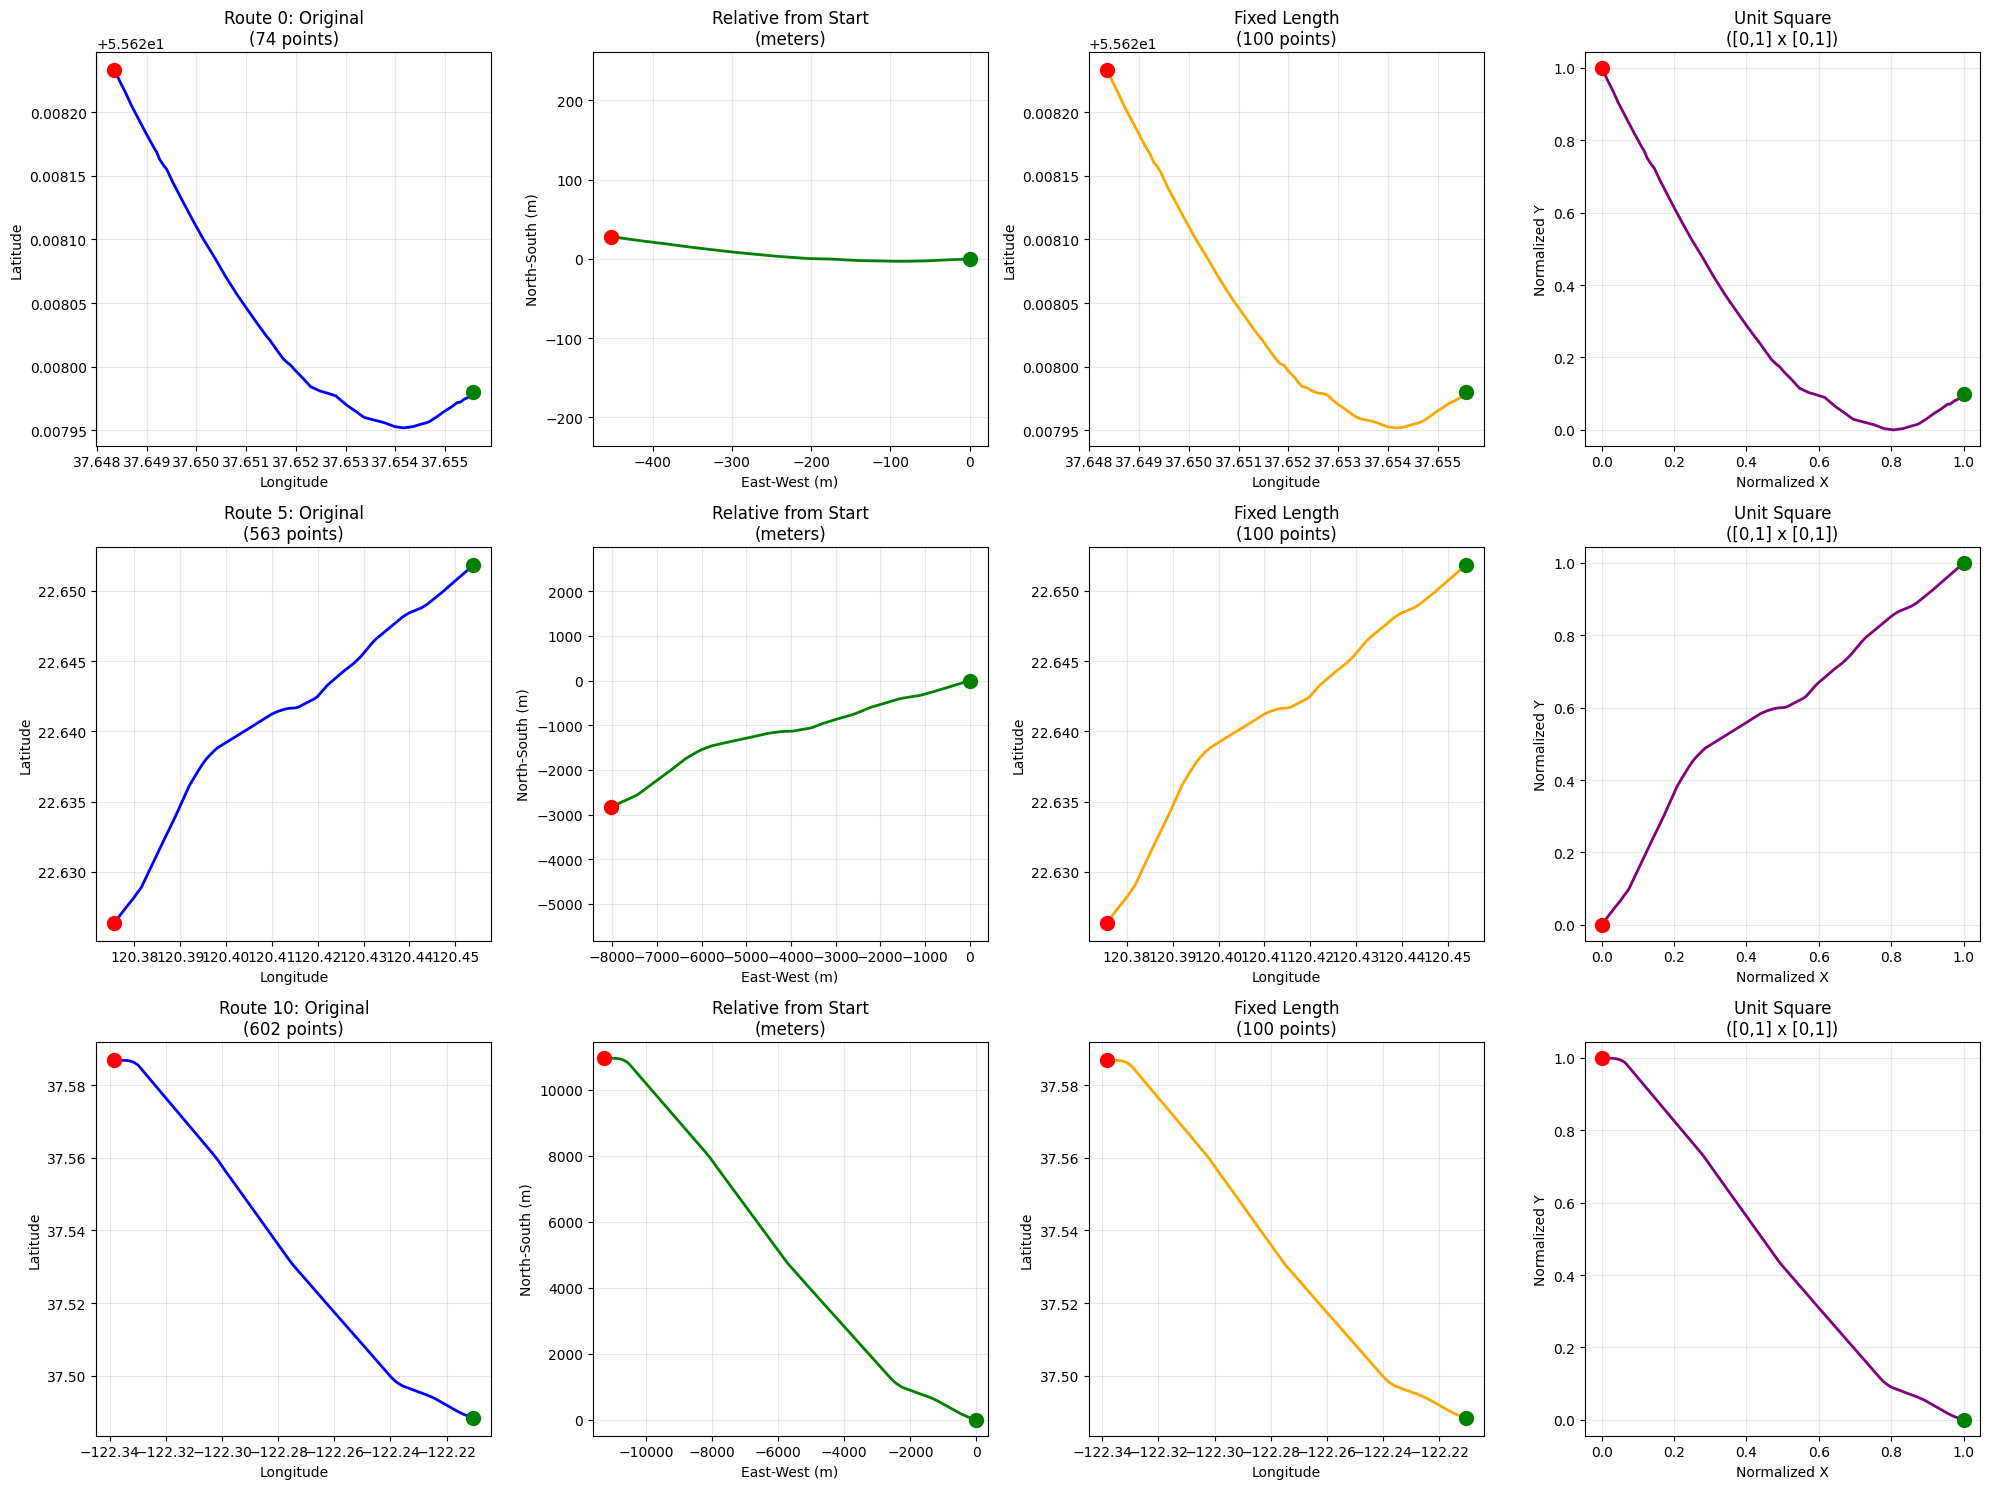

🎨 Visualization complete!
Green dot = Start, Red dot = End

Notice how:
- Column 1: Original routes in different locations
- Column 2: All start at (0,0), preserving actual distances
- Column 3: Resampled to same number of points
- Column 4: All scaled to fit in [0,1] x [0,1] square


In [21]:
import matplotlib.pyplot as plt

# Get 3 different routes
routes_to_compare = [0, 5, 10]
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for row_idx, route_idx in enumerate(routes_to_compare):
    route = get_data_by_index(route_idx)
    geometry = route.get('geometry', [])
    
    if not geometry:
        continue
    
    # Original
    ax = axes[row_idx, 0]
    lons = [p[0] for p in geometry]
    lats = [p[1] for p in geometry]
    ax.plot(lons, lats, 'b-', linewidth=2)
    ax.scatter(lons[0], lats[0], color='green', s=100, zorder=5)
    ax.scatter(lons[-1], lats[-1], color='red', s=100, zorder=5)
    ax.set_title(f'Route {route_idx}: Original\n({len(geometry)} points)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, alpha=0.3)
    
    # Method 1: Relative distances
    norm1 = normalize_route_relative(geometry)
    if norm1 is not None:
        ax = axes[row_idx, 1]
        ax.plot(norm1[:, 0], norm1[:, 1], 'g-', linewidth=2)
        ax.scatter(norm1[0, 0], norm1[0, 1], color='green', s=100, zorder=5)
        ax.scatter(norm1[-1, 0], norm1[-1, 1], color='red', s=100, zorder=5)
        ax.set_title(f'Relative from Start\n(meters)')
        ax.set_xlabel('East-West (m)')
        ax.set_ylabel('North-South (m)')
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
    
    # Method 2: Fixed length (100 points)
    norm2 = normalize_route_fixed_length(geometry, n_points=100)
    if norm2 is not None:
        ax = axes[row_idx, 2]
        lons2 = norm2[:, 0]
        lats2 = norm2[:, 1]
        ax.plot(lons2, lats2, 'orange', linewidth=2)
        ax.scatter(lons2[0], lats2[0], color='green', s=100, zorder=5)
        ax.scatter(lons2[-1], lats2[-1], color='red', s=100, zorder=5)
        ax.set_title(f'Fixed Length\n(100 points)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(True, alpha=0.3)
    
    # Method 3: Unit square
    norm3 = normalize_route_unit_square(geometry)
    if norm3 is not None:
        ax = axes[row_idx, 3]
        ax.plot(norm3[:, 0], norm3[:, 1], 'purple', linewidth=2)
        ax.scatter(norm3[0, 0], norm3[0, 1], color='green', s=100, zorder=5)
        ax.scatter(norm3[-1, 0], norm3[-1, 1], color='red', s=100, zorder=5)
        ax.set_title(f'Unit Square\n([0,1] x [0,1])')
        ax.set_xlabel('Normalized X')
        ax.set_ylabel('Normalized Y')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.1)
        ax.axis('equal')

plt.tight_layout()
plt.show()

print("🎨 Visualization complete!")
print("Green dot = Start, Red dot = End")
print("\nNotice how:")
print("- Column 1: Original routes in different locations")
print("- Column 2: All start at (0,0), preserving actual distances")
print("- Column 3: Resampled to same number of points")
print("- Column 4: All scaled to fit in [0,1] x [0,1] square")

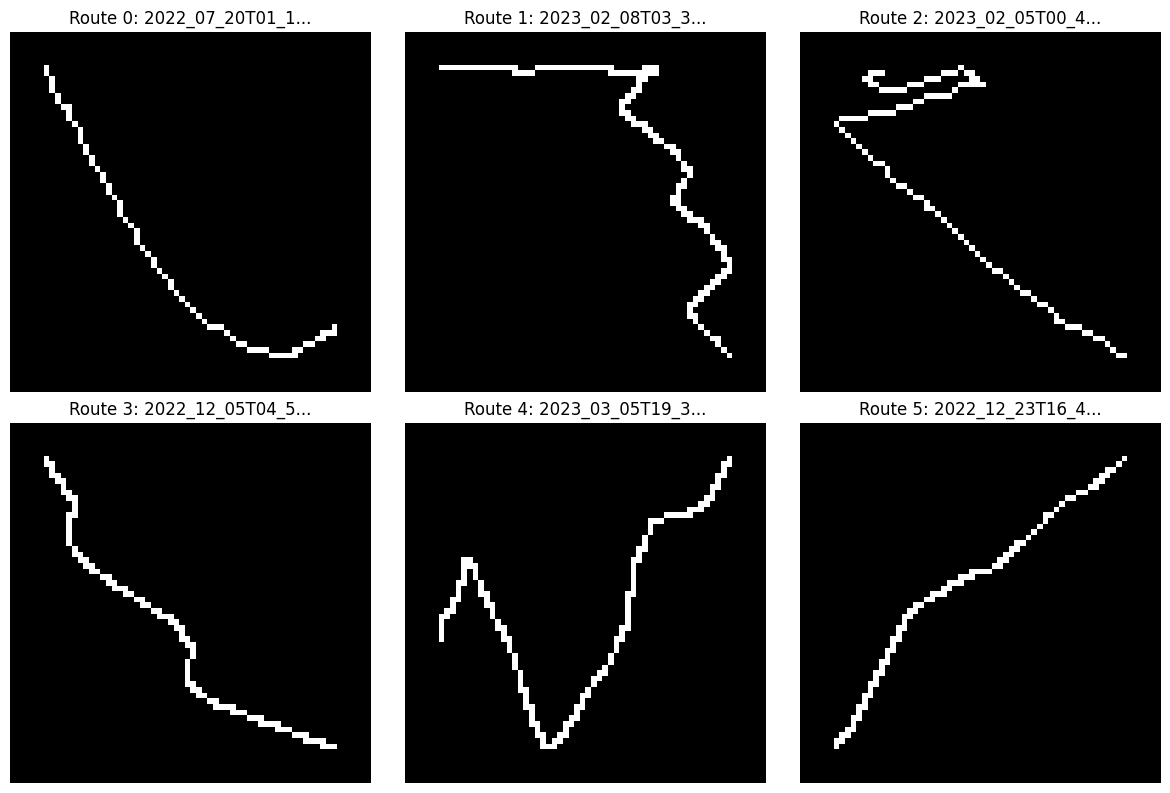

✅ Image conversion complete!
Image shape: (64, 64)

💡 These images can be fed directly into your Siamese CNN!
   - All routes are position-independent (relative coordinates)
   - Fixed 64x64 size
   - Ready for contrastive learning


In [22]:
# Image-based approach: Convert routes to binary images for CNN
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def route_to_image(geometry, img_size=64):
    """
    Convert a route to a binary image for CNN processing.
    Uses relative distances so position doesn't matter.
    """
    if not geometry or len(geometry) < 2:
        return None
    
    # Step 1: Normalize to relative distances from start
    norm_route = normalize_route_relative(geometry)
    
    # Step 2: Scale to fit in image (with padding)
    min_x, min_y = norm_route.min(axis=0)
    max_x, max_y = norm_route.max(axis=0)
    
    # Add 10% padding
    padding = 0.1
    range_x = max_x - min_x
    range_y = max_y - min_y
    
    if range_x == 0:
        range_x = 1
    if range_y == 0:
        range_y = 1
    
    # Scale to image coordinates
    scaled_x = ((norm_route[:, 0] - min_x) / range_x) * (img_size * (1 - 2*padding)) + img_size * padding
    scaled_y = ((norm_route[:, 1] - min_y) / range_y) * (img_size * (1 - 2*padding)) + img_size * padding
    
    # Create blank image
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    
    # Draw the route as connected lines
    for i in range(len(scaled_x) - 1):
        x1, y1 = int(scaled_x[i]), int(img_size - scaled_y[i])  # Flip Y
        x2, y2 = int(scaled_x[i+1]), int(img_size - scaled_y[i+1])
        
        # Draw line using Bresenham's algorithm (simple version)
        steps = max(abs(x2 - x1), abs(y2 - y1))
        if steps > 0:
            for t in range(steps + 1):
                x = int(x1 + (x2 - x1) * t / steps)
                y = int(y1 + (y2 - y1) * t / steps)
                if 0 <= x < img_size and 0 <= y < img_size:
                    img[y, x] = 255
    
    return img

# Test: Convert 6 different routes to images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    route = get_data_by_index(i)
    geometry = route.get('geometry', [])
    
    img = route_to_image(geometry, img_size=64)
    
    if img is not None:
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Route {i}: {route.get("Filename", "Unknown")[:15]}...')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

print("✅ Image conversion complete!")
print(f"Image shape: {img.shape if img is not None else 'N/A'}")
print("\n💡 These images can be fed directly into your Siamese CNN!")
print("   - All routes are position-independent (relative coordinates)")
print("   - Fixed 64x64 size")
print("   - Ready for contrastive learning")

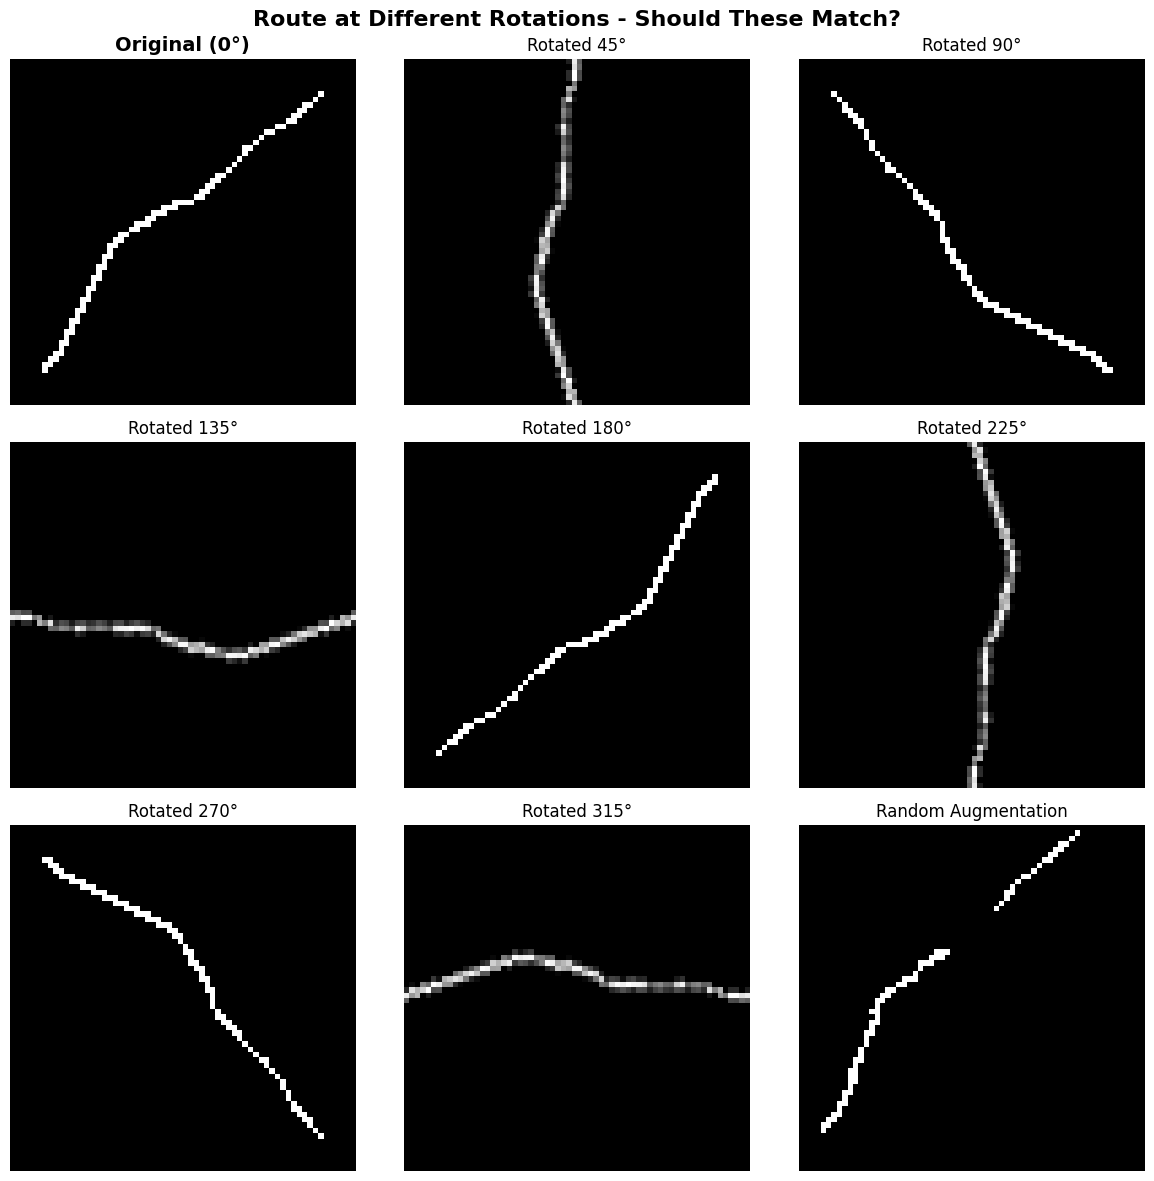

✅ Rotation demonstration complete!

🤔 Key Question: Should rotated versions be considered SIMILAR?
   - If YES → Use canonical orientation to align them first
   - If NO → Direction matters, keep them as different

💡 For running routes, shape usually matters more than direction:
   → Canonical orientation is recommended!
   → Then add small augmentations (±15°) for robustness


In [23]:
import torch
import torchvision.transforms as T
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Data augmentation for route images (to create positive pairs)
class RouteImageAugmentation:
    """
    Augmentation strategies for self-supervised learning on route images.
    Same route + different augmentations = positive pair
    """
    def __init__(self, img_size=64):
        self.img_size = img_size
        
        # Define augmentation pipeline
        self.transform = T.Compose([
            T.RandomRotation(degrees=15),  # Small rotation
            T.RandomAffine(
                degrees=0,
                translate=(0.1, 0.1),  # Small shift
                scale=(0.9, 1.1),  # Small zoom
            ),
            T.RandomApply([
                T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
            ], p=0.3),
            T.RandomApply([
                T.Lambda(lambda x: self.add_noise(x))
            ], p=0.3),
            T.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # Random dropout
        ])
    
    def add_noise(self, img_tensor):
        """Add Gaussian noise"""
        noise = torch.randn_like(img_tensor) * 0.1
        return torch.clamp(img_tensor + noise, 0, 1)
    
    def __call__(self, img_array):
        """
        Apply augmentation to numpy array
        Args:
            img_array: (H, W) numpy array (0-255)
        Returns:
            augmented tensor: (1, H, W) normalized to [0, 1]
        """
        # Convert to PIL Image
        pil_img = Image.fromarray(img_array)
        
        # Convert to tensor and normalize
        img_tensor = T.ToTensor()(pil_img)  # (1, H, W), [0, 1]
        
        # Apply augmentations
        augmented = self.transform(img_tensor)
        
        return augmented

# Test augmentation on a route
augmenter = RouteImageAugmentation(img_size=64)

# Get a route and convert to image
route = get_data_by_index(5)
geometry = route.get('geometry', [])
original_img = route_to_image(geometry, img_size=64)

# Show route with different rotations (to demonstrate rotation invariance need)
from scipy.ndimage import rotate as scipy_rotate

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Original
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title('Original (0°)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# 8 different rotations: 45°, 90°, 135°, 180°, 225°, 270°, 315°, and one random augmentation
rotation_angles = [45, 90, 135, 180, 225, 270, 315]
for i, angle in enumerate(rotation_angles, start=1):
    rotated_img = scipy_rotate(original_img, angle, reshape=False, order=1)
    
    axes[i].imshow(rotated_img, cmap='gray')
    axes[i].set_title(f'Rotated {angle}°', fontsize=12)
    axes[i].axis('off')

# Last one: show a random augmentation with other transforms
aug_tensor = augmenter(original_img)
aug_img = aug_tensor.squeeze().numpy()
axes[8].imshow(aug_img, cmap='gray')
axes[8].set_title('Random Augmentation', fontsize=12)
axes[8].axis('off')

plt.suptitle('Route at Different Rotations - Should These Match?', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Rotation demonstration complete!")
print("\n🤔 Key Question: Should rotated versions be considered SIMILAR?")
print("   - If YES → Use canonical orientation to align them first")
print("   - If NO → Direction matters, keep them as different")
print("\n💡 For running routes, shape usually matters more than direction:")
print("   → Canonical orientation is recommended!")
print("   → Then add small augmentations (±15°) for robustness")

In [24]:
import torch.nn as nn
import torch.nn.functional as F
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Euclidean distance
        euclidean_distance = F.pairwise_distance(output1, output2)
        
        # Calculate loss
        # Label 0: Similar (pull together) -> minimize distance
        # Label 1: Dissimilar (push apart) -> maximize distance up to margin
        loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

In [25]:
# Simple CNN for route image embedding
import torch.nn as nn
import torch.nn.functional as F

class RouteCNN(nn.Module):
    """
    Simple CNN to extract features from route images.
    Input: (batch, 1, 64, 64) grayscale route images
    Output: (batch, 128) embedding vectors
    """
    def __init__(self, embedding_dim=128):
        super(RouteCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)  # 64 -> 32
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 32 -> 16
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 16 -> 8
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, embedding_dim)
    
    def forward(self, x):
        # Convolutional layers with ReLU and pooling
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        # L2 normalization for better contrastive learning
        x = F.normalize(x, p=2, dim=1)
        
        return x

# Test the network
model = RouteCNN(embedding_dim=128)
print(f"✅ Model created!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test with a dummy input
dummy_input = torch.randn(4, 1, 64, 64)  # Batch of 4 images
output = model(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output range: [{output.min().item():.3f}, {output.max().item():.3f}]")

print("\n📊 Model architecture:")
print(model)

✅ Model created!
Total parameters: 4,354,112

Input shape: torch.Size([4, 1, 64, 64])
Output shape: torch.Size([4, 128])
Output range: [-0.259, 0.257]

📊 Model architecture:
RouteCNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=Tr

In [26]:
# PyTorch Dataset for route pairs
from torch.utils.data import Dataset, DataLoader

class RouteDataset(Dataset):
    """
    Dataset for contrastive learning on route images.
    Returns pairs of images with labels:
    - Label 0: Same route (positive pair)
    - Label 1: Different routes (negative pair)
    """
    def __init__(self, jsonl_path, num_routes=1000, augmenter=None):
        self.jsonl_path = jsonl_path
        self.num_routes = num_routes
        self.augmenter = augmenter or RouteImageAugmentation()
        
        print(f"Loading {num_routes} routes...")
        self.routes = []
        with open(jsonl_path, 'r') as f:
            for i, line in enumerate(f):
                if i >= num_routes:
                    break
                route = json.loads(line)
                geometry = route.get('geometry', [])
                if geometry and len(geometry) >= 2:
                    # Convert to image immediately
                    img = route_to_image(geometry, img_size=64)
                    if img is not None:
                        self.routes.append(img)
        
        print(f"✅ Loaded {len(self.routes)} valid routes")
    
    def __len__(self):
        # Each epoch we generate synthetic pairs
        return len(self.routes) * 2  # 2x because we make 1 positive + 1 negative per route
    
    def __getitem__(self, idx):
        # 50% chance: positive pair (same route, different augmentations)
        # 50% chance: negative pair (different routes)
        
        if idx % 2 == 0:
            # Positive pair: same route with 2 different augmentations
            route_idx = (idx // 2) % len(self.routes)
            img = self.routes[route_idx]
            
            # Apply 2 different augmentations
            img1_tensor = self.augmenter(img)
            img2_tensor = self.augmenter(img)
            
            label = torch.tensor(0.0)  # 0 = similar
        else:
            # Negative pair: 2 different routes
            route_idx1 = (idx // 2) % len(self.routes)
            route_idx2 = (route_idx1 + np.random.randint(1, len(self.routes))) % len(self.routes)
            
            img1 = self.routes[route_idx1]
            img2 = self.routes[route_idx2]
            
            # Apply augmentation to each
            img1_tensor = self.augmenter(img1)
            img2_tensor = self.augmenter(img2)
            
            label = torch.tensor(1.0)  # 1 = dissimilar
        
        return img1_tensor, img2_tensor, label

# Create dataset and dataloader
dataset = RouteDataset("WorldTrace_20k.jsonl", num_routes=1000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"\n📦 Dataset ready!")
print(f"   Total samples per epoch: {len(dataset)}")
print(f"   Batches per epoch: {len(dataloader)}")
print(f"   Batch size: 32")

# Test the dataloader
img1, img2, labels = next(iter(dataloader))
print(f"\n🔍 Sample batch:")
print(f"   Image 1 shape: {img1.shape}")
print(f"   Image 2 shape: {img2.shape}")
print(f"   Labels shape: {labels.shape}")
print(f"   Positive pairs: {(labels == 0).sum().item()}")
print(f"   Negative pairs: {(labels == 1).sum().item()}")

Loading 1000 routes...
✅ Loaded 1000 valid routes

📦 Dataset ready!
   Total samples per epoch: 2000
   Batches per epoch: 63
   Batch size: 32

🔍 Sample batch:
   Image 1 shape: torch.Size([32, 1, 64, 64])
   Image 2 shape: torch.Size([32, 1, 64, 64])
   Labels shape: torch.Size([32])
   Positive pairs: 17
   Negative pairs: 15


🖥️  Using device: cpu

🚀 Starting training for 5 epochs...


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 0.5997


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/5 - Loss: 0.4934


...

Epoch 3/5 - Loss: 0.4739


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.4555


Training:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.4370

✅ Training complete!


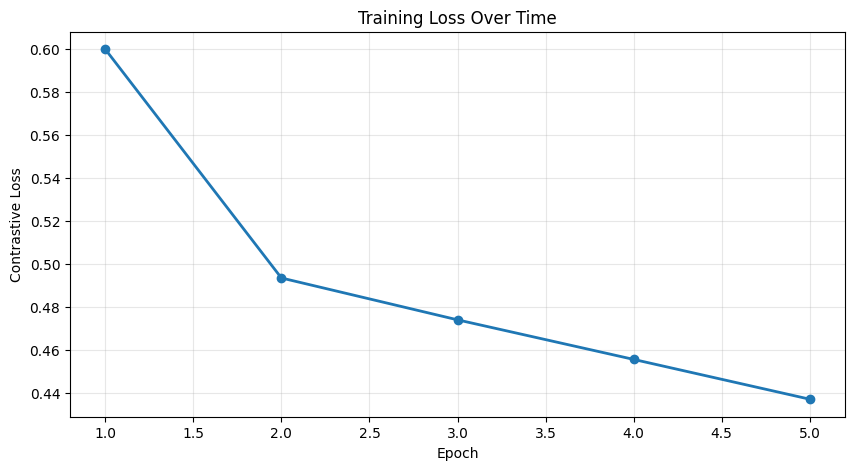


Final loss: 0.4370


In [27]:
# Training loop with contrastive loss
import torch.optim as optim
from tqdm.auto import tqdm

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {device}")

# Initialize model, loss, and optimizer
model = RouteCNN(embedding_dim=128).to(device)
criterion = ContrastiveLoss(margin=2.0)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for img1, img2, labels in tqdm(dataloader, desc="Training"):
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        output1 = model(img1)
        output2 = model(img2)
        
        # Calculate loss
        loss = criterion(output1, output2, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Train for a few epochs
num_epochs = 5
print(f"\n🚀 Starting training for {num_epochs} epochs...")
print("=" * 60)

history = {'loss': []}

for epoch in range(num_epochs):
    avg_loss = train_epoch(model, dataloader, criterion, optimizer, device)
    history['loss'].append(avg_loss)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

print("\n✅ Training complete!")

# Plot training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), history['loss'], marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {history['loss'][-1]:.4f}")

🔍 Finding similar routes using the trained model...
Computing embeddings for all routes...
✅ Generated 1000 embeddings

📍 Query Route: #0
Finding 5 most similar routes...



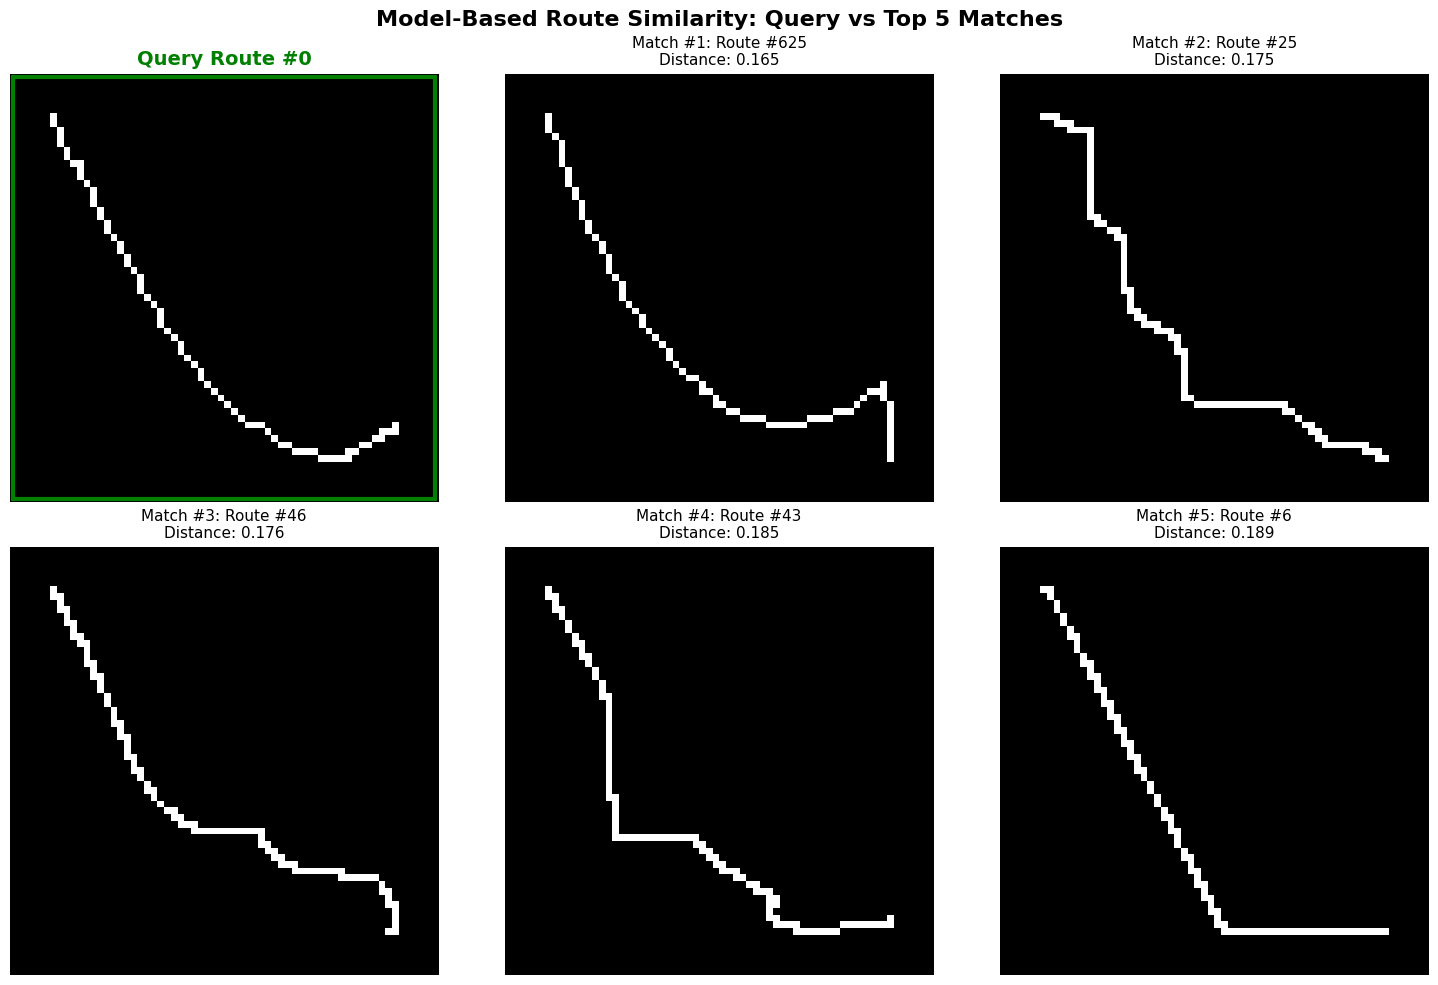

📊 Similarity Results:
   Query: Route #0
   1. Route #625 - Distance: 0.165
   2. Route #25 - Distance: 0.175
   3. Route #46 - Distance: 0.176
   4. Route #43 - Distance: 0.185
   5. Route #6 - Distance: 0.189

💡 Interpretation:
   - Lower distance = more similar route shapes
   - The model learned to identify similar patterns!
   - Distances are in embedding space (not pixels)


In [28]:
# Test the trained model: Find most similar routes
print("🔍 Finding similar routes using the trained model...")

# Get embeddings for all routes
model.eval()
embeddings = []

print("Computing embeddings for all routes...")
with torch.no_grad():
    for i in range(len(dataset.routes)):
        img = dataset.routes[i]
        # Convert to tensor
        img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
        img_tensor = img_tensor.to(device)
        
        # Get embedding
        embedding = model(img_tensor)
        embeddings.append(embedding.cpu().numpy())

embeddings = np.vstack(embeddings)
print(f"✅ Generated {len(embeddings)} embeddings")

# Pick the first route as query
query_idx = 0
query_embedding = embeddings[query_idx]

# Compute distances to all other routes
distances = np.linalg.norm(embeddings - query_embedding, axis=1)

# Get top 5 most similar routes (excluding itself)
most_similar_indices = np.argsort(distances)[1:6]  # Skip index 0 (itself)

print(f"\n📍 Query Route: #{query_idx}")
print(f"Finding 5 most similar routes...\n")

# Visualize the query route and its 5 most similar matches
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot query route
axes[0].imshow(dataset.routes[query_idx], cmap='gray')
axes[0].set_title(f'Query Route #{query_idx}', fontsize=14, fontweight='bold', color='green')
axes[0].axis('off')
axes[0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='green', linewidth=3))

# Plot 5 most similar routes
for i, similar_idx in enumerate(most_similar_indices, start=1):
    axes[i].imshow(dataset.routes[similar_idx], cmap='gray')
    distance = distances[similar_idx]
    axes[i].set_title(f'Match #{i}: Route #{similar_idx}\nDistance: {distance:.3f}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Model-Based Route Similarity: Query vs Top 5 Matches', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Similarity Results:")
print(f"   Query: Route #{query_idx}")
for rank, similar_idx in enumerate(most_similar_indices, start=1):
    distance = distances[similar_idx]
    print(f"   {rank}. Route #{similar_idx} - Distance: {distance:.3f}")

print("\n💡 Interpretation:")
print("   - Lower distance = more similar route shapes")
print("   - The model learned to identify similar patterns!")
print("   - Distances are in embedding space (not pixels)")

🔍 Finding similar routes for first 10 query routes...
✅ Processed 10 query routes



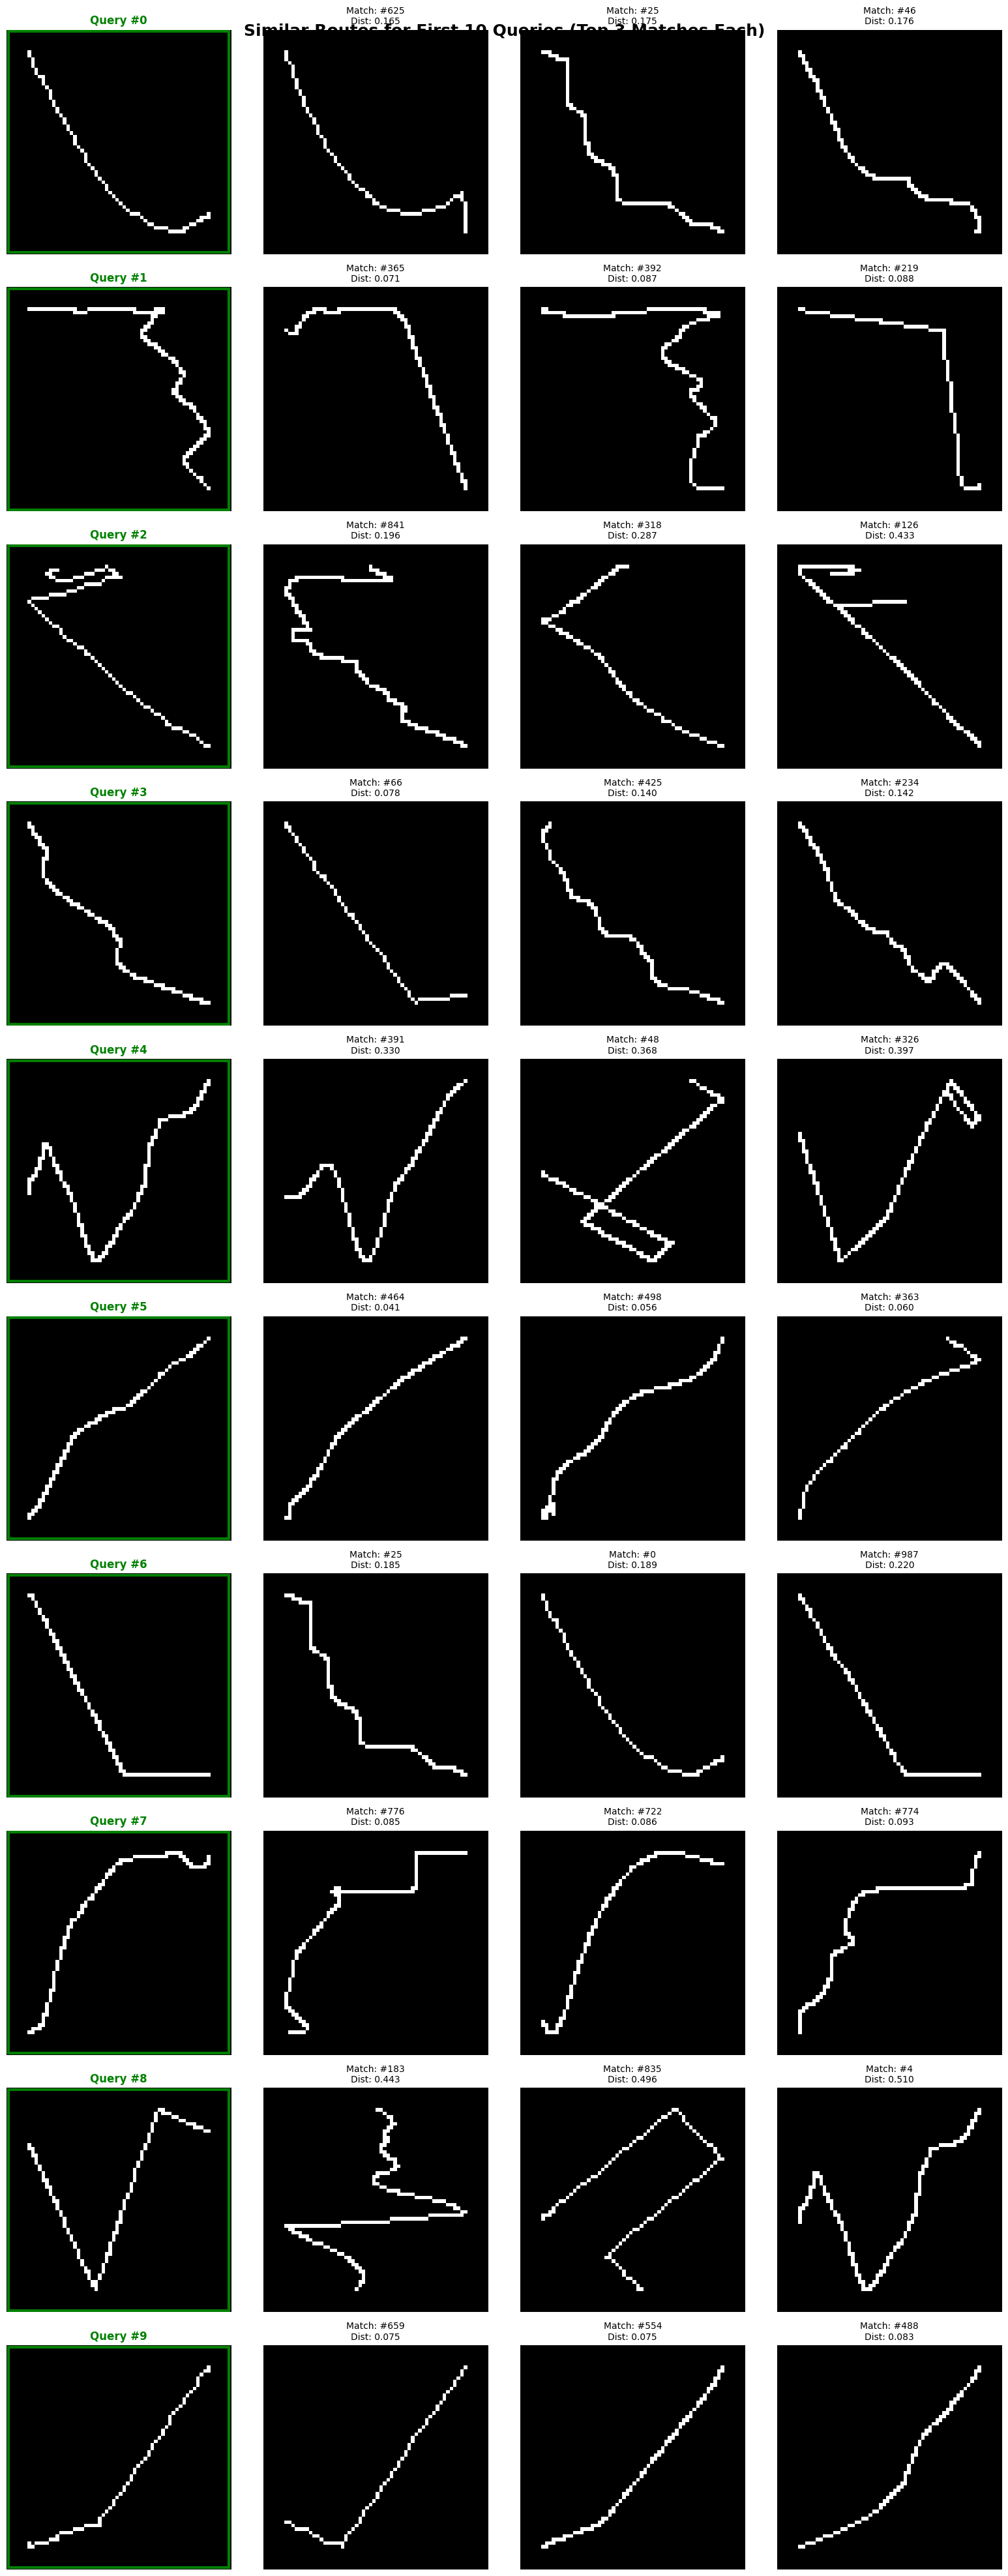


📊 Similarity Summary:

Query Route #0:
   1. Route #625 - Distance: 0.165
   2. Route #25 - Distance: 0.175
   3. Route #46 - Distance: 0.176

Query Route #1:
   1. Route #365 - Distance: 0.071
   2. Route #392 - Distance: 0.087
   3. Route #219 - Distance: 0.088

Query Route #2:
   1. Route #841 - Distance: 0.196
   2. Route #318 - Distance: 0.287
   3. Route #126 - Distance: 0.433

Query Route #3:
   1. Route #66 - Distance: 0.078
   2. Route #425 - Distance: 0.140
   3. Route #234 - Distance: 0.142

Query Route #4:
   1. Route #391 - Distance: 0.330
   2. Route #48 - Distance: 0.368
   3. Route #326 - Distance: 0.397

Query Route #5:
   1. Route #464 - Distance: 0.041
   2. Route #498 - Distance: 0.056
   3. Route #363 - Distance: 0.060

Query Route #6:
   1. Route #25 - Distance: 0.185
   2. Route #0 - Distance: 0.189
   3. Route #987 - Distance: 0.220

Query Route #7:
   1. Route #776 - Distance: 0.085
   2. Route #722 - Distance: 0.086
   3. Route #774 - Distance: 0.093

Query R

In [29]:
# Find similar routes for first 10 routes
print("🔍 Finding similar routes for first 10 query routes...")

# We already have embeddings for all routes from previous cell
# Just recompute if needed
if 'embeddings' not in locals():
    model.eval()
    embeddings = []
    print("Computing embeddings for all routes...")
    with torch.no_grad():
        for i in range(len(dataset.routes)):
            img = dataset.routes[i]
            img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
            img_tensor = img_tensor.to(device)
            embedding = model(img_tensor)
            embeddings.append(embedding.cpu().numpy())
    embeddings = np.vstack(embeddings)

# Process first 10 routes
num_queries = 10
results = []

for query_idx in range(num_queries):
    query_embedding = embeddings[query_idx]
    
    # Compute distances to all other routes
    distances = np.linalg.norm(embeddings - query_embedding, axis=1)
    
    # Get top 3 most similar routes (excluding itself)
    most_similar_indices = np.argsort(distances)[1:4]  # Top 3 matches
    
    results.append({
        'query_idx': query_idx,
        'matches': most_similar_indices,
        'distances': distances[most_similar_indices]
    })

print(f"✅ Processed {num_queries} query routes\n")

# Visualize all results in a grid
fig, axes = plt.subplots(num_queries, 4, figsize=(16, 4*num_queries))

for row, result in enumerate(results):
    query_idx = result['query_idx']
    matches = result['matches']
    match_distances = result['distances']
    
    # Column 0: Query route
    axes[row, 0].imshow(dataset.routes[query_idx], cmap='gray')
    axes[row, 0].set_title(f'Query #{query_idx}', fontsize=12, fontweight='bold', color='green')
    axes[row, 0].axis('off')
    axes[row, 0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='green', linewidth=3))
    
    # Columns 1-3: Top 3 matches
    for col, (match_idx, dist) in enumerate(zip(matches, match_distances), start=1):
        axes[row, col].imshow(dataset.routes[match_idx], cmap='gray')
        axes[row, col].set_title(f'Match: #{match_idx}\nDist: {dist:.3f}', fontsize=10)
        axes[row, col].axis('off')

plt.suptitle('Similar Routes for First 10 Queries (Top 3 Matches Each)', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n📊 Similarity Summary:")
print("=" * 60)
for result in results:
    query_idx = result['query_idx']
    matches = result['matches']
    match_distances = result['distances']
    
    print(f"\nQuery Route #{query_idx}:")
    for rank, (match_idx, dist) in enumerate(zip(matches, match_distances), start=1):
        print(f"   {rank}. Route #{match_idx} - Distance: {dist:.3f}")

print("\n💡 Lower distances indicate more similar route shapes!")

In [30]:
print(get_data_by_index(1))


{'Filename': '2023_02_08T03_37_45.045645Z.gpx', 'Uploaded': ' 9 February 2023 at 03:50', 'Points': 600, 'Start coordinate': ['42.34847039209213', '-71.10443325547672'], 'Owner': 'sunnypilot', 'Description': 'Routes from sunnypilot 2022.12.16 (HYUNDAI SANTA FE 2022).', 'Tags': 'None', 'Visibility': 'Identifiable (shown in trace list and as identifiable, ordered points with timestamps)', 'Distance': 15028.128753511506, 'Time': 4802, 'geometry': [[-71.104441, 42.348447], [-71.104221, 42.348405], [-71.104026, 42.348368], [-71.104004, 42.348363], [-71.103788, 42.348322], [-71.103572, 42.348281], [-71.103354, 42.348239], [-71.103136, 42.348197], [-71.102919, 42.348156], [-71.102705, 42.348115], [-71.102494, 42.348075], [-71.102291, 42.348036], [-71.102099, 42.347999], [-71.101922, 42.347965], [-71.101839, 42.34795], [-71.101757, 42.347935], [-71.101598, 42.347906], [-71.101558, 42.347899], [-71.101438, 42.347879], [-71.101278, 42.347853], [-71.101259, 42.34785], [-71.101111, 42.347834], [-71

In [31]:
print(get_data_by_index(0))

{'Filename': '2022_07_20T01_18_27.591242Z.gpx', 'Uploaded': '22 July 2023 at 05:52', 'Points': 58, 'Start coordinate': ['55.627981623288896', '37.65556577791681'], 'Owner': 'dragonpilot', 'Description': 'Routes from dragonpilot 2023.04.13 (VOLKSWAGEN TIGUAN 2ND GEN).', 'Tags': 'None', 'Visibility': 'Identifiable (shown in trace list and as identifiable, ordered points with timestamps)', 'Distance': 455.6308553917523, 'Time': 178, 'geometry': [[37.655566, 55.62798], [37.655565, 55.627979], [37.655559, 55.627979], [37.655554, 55.627979], [37.655552, 55.627979], [37.655549, 55.627979], [37.65554, 55.627979], [37.655526, 55.627978], [37.655503, 55.627977], [37.655464, 55.627976], [37.655419, 55.627975], [37.655406, 55.627975], [37.655366, 55.627974], [37.655299, 55.627972], [37.65525, 55.627972], [37.655216, 55.627971], [37.655112, 55.627968], [37.654986, 55.627965], [37.654846, 55.627961], [37.654689, 55.627957], [37.65463, 55.627956], [37.654526, 55.627955], [37.654361, 55.627953], [37.6

📊 Loading routes to analyze distributions...
✅ Loaded 20000 routes with terrain data


/var/folders/m3/2m8_fl_d4ddgncptvm0qqhsh0000gn/T/ipykernel_32186/1358476772.py:102: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(pace_data, labels=terrain_names, patch_artist=True)


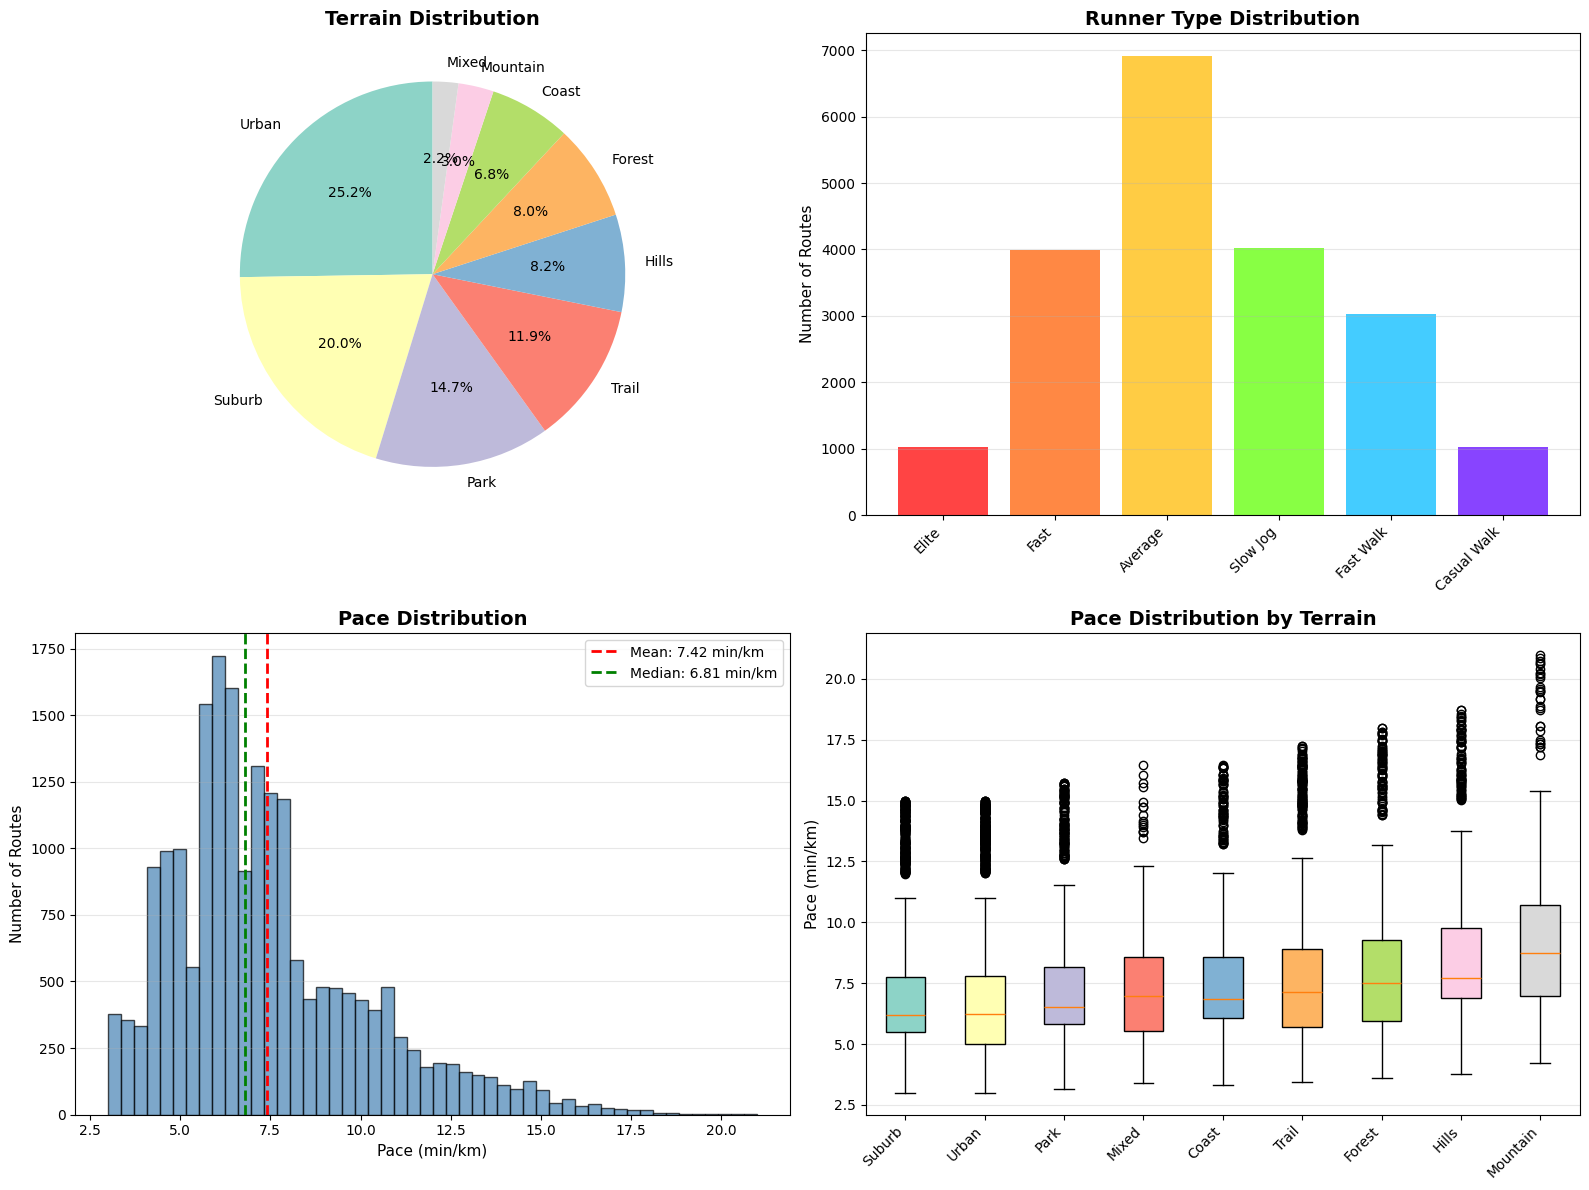


📈 DISTRIBUTION STATISTICS

🌍 Terrain Distribution:
   Urban       :  5049 routes ( 25.2%)
   Suburb      :  4001 routes ( 20.0%)
   Park        :  2933 routes ( 14.7%)
   Trail       :  2386 routes ( 11.9%)
   Hills       :  1632 routes (  8.2%)
   Forest      :  1608 routes (  8.0%)
   Coast       :  1367 routes (  6.8%)
   Mountain    :   593 routes (  3.0%)
   Mixed       :   431 routes (  2.2%)

🏃 Runner Type Distribution:
   Elite          :  1022 routes (  5.1%)
   Fast           :  3993 routes ( 20.0%)
   Average        :  6909 routes ( 34.5%)
   Slow Jog       :  4022 routes ( 20.1%)
   Fast Walk      :  3022 routes ( 15.1%)
   Casual Walk    :  1032 routes (  5.2%)

⚡ Pace Statistics:
   Mean:   7.42 min/km
   Median: 6.81 min/km
   Min:    3.00 min/km
   Max:    20.99 min/km
   Std:    2.75 min/km

🏔️  Average Pace by Terrain:
   Suburb      : 6.85 min/km
   Urban       : 6.88 min/km
   Park        : 7.19 min/km
   Mixed       : 7.51 min/km
   Coast       : 7.55 min/km
   Tr

In [32]:
# Visualize terrain and running speed distributions
import matplotlib.pyplot as plt
import json
import numpy as np

print("📊 Loading routes to analyze distributions...")

# Load all routes
terrains = []
runner_types = []
paces = []
distances = []

with open('WorldTrace_20k.jsonl', 'r') as f:
    for line in f:
        route = json.loads(line)
        if 'Terrain' in route:
            terrains.append(route['Terrain'])
        if 'RunnerType' in route:
            runner_types.append(route['RunnerType'])
        if 'PaceMinPerKm' in route:
            paces.append(route['PaceMinPerKm'])
        if 'Distance' in route:
            distances.append(route['Distance'] / 1000.0)  # Convert to km

print(f"✅ Loaded {len(terrains)} routes with terrain data")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Terrain Distribution (Pie Chart)
if terrains:
    terrain_counts = {}
    for t in terrains:
        terrain_counts[t] = terrain_counts.get(t, 0) + 1
    
    sorted_terrains = sorted(terrain_counts.items(), key=lambda x: x[1], reverse=True)
    terrain_labels = [t[0].title() for t in sorted_terrains]
    terrain_values = [t[1] for t in sorted_terrains]
    
    colors = plt.cm.Set3(range(len(terrain_labels)))
    
    axes[0, 0].pie(terrain_values, labels=terrain_labels, autopct='%1.1f%%',
                   colors=colors, startangle=90)
    axes[0, 0].set_title('Terrain Distribution', fontsize=14, fontweight='bold')

# 2. Runner Type Distribution (Bar Chart)
if runner_types:
    runner_counts = {}
    for rt in runner_types:
        runner_counts[rt] = runner_counts.get(rt, 0) + 1
    
    sorted_runners = sorted(runner_counts.items(), 
                           key=lambda x: ['elite', 'fast', 'average', 'slow_jog', 'fast_walk', 'casual_walk'].index(x[0]) 
                           if x[0] in ['elite', 'fast', 'average', 'slow_jog', 'fast_walk', 'casual_walk'] else 999)
    
    runner_labels = [r[0].replace('_', ' ').title() for r in sorted_runners]
    runner_values = [r[1] for r in sorted_runners]
    
    colors_runner = ['#ff4444', '#ff8844', '#ffcc44', '#88ff44', '#44ccff', '#8844ff'][:len(runner_labels)]
    
    axes[0, 1].bar(range(len(runner_labels)), runner_values, color=colors_runner)
    axes[0, 1].set_xticks(range(len(runner_labels)))
    axes[0, 1].set_xticklabels(runner_labels, rotation=45, ha='right')
    axes[0, 1].set_ylabel('Number of Routes', fontsize=11)
    axes[0, 1].set_title('Runner Type Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Pace Distribution (Histogram)
if paces:
    axes[1, 0].hist(paces, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Pace (min/km)', fontsize=11)
    axes[1, 0].set_ylabel('Number of Routes', fontsize=11)
    axes[1, 0].set_title('Pace Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].axvline(np.mean(paces), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(paces):.2f} min/km')
    axes[1, 0].axvline(np.median(paces), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(paces):.2f} min/km')
    axes[1, 0].legend()
    axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Pace by Terrain (Box Plot)
if terrains and paces:
    # Group paces by terrain
    terrain_pace_data = {}
    
    with open('WorldTrace_20k.jsonl', 'r') as f:
        for line in f:
            route = json.loads(line)
            if 'Terrain' in route and 'PaceMinPerKm' in route:
                terrain = route['Terrain']
                pace = route['PaceMinPerKm']
                if terrain not in terrain_pace_data:
                    terrain_pace_data[terrain] = []
                terrain_pace_data[terrain].append(pace)
    
    # Sort by average pace
    sorted_terrain_pace = sorted(terrain_pace_data.items(), 
                                 key=lambda x: np.mean(x[1]))
    
    terrain_names = [t[0].title() for t in sorted_terrain_pace]
    pace_data = [t[1] for t in sorted_terrain_pace]
    
    bp = axes[1, 1].boxplot(pace_data, labels=terrain_names, patch_artist=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(terrain_names)))):
        patch.set_facecolor(color)
    
    axes[1, 1].set_xticklabels(terrain_names, rotation=45, ha='right')
    axes[1, 1].set_ylabel('Pace (min/km)', fontsize=11)
    axes[1, 1].set_title('Pace Distribution by Terrain', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "=" * 70)
print("📈 DISTRIBUTION STATISTICS")
print("=" * 70)

if terrains:
    print("\n🌍 Terrain Distribution:")
    for terrain, count in sorted_terrains:
        pct = (count / len(terrains)) * 100
        print(f"   {terrain.title():12s}: {count:5d} routes ({pct:5.1f}%)")

if runner_types:
    print("\n🏃 Runner Type Distribution:")
    for runner, count in sorted_runners:
        pct = (count / len(runner_types)) * 100
        print(f"   {runner.replace('_', ' ').title():15s}: {count:5d} routes ({pct:5.1f}%)")

if paces:
    print(f"\n⚡ Pace Statistics:")
    print(f"   Mean:   {np.mean(paces):.2f} min/km")
    print(f"   Median: {np.median(paces):.2f} min/km")
    print(f"   Min:    {np.min(paces):.2f} min/km")
    print(f"   Max:    {np.max(paces):.2f} min/km")
    print(f"   Std:    {np.std(paces):.2f} min/km")

if terrain_pace_data:
    print(f"\n🏔️  Average Pace by Terrain:")
    for terrain, paces_list in sorted_terrain_pace:
        avg_pace = np.mean(paces_list)
        print(f"   {terrain.title():12s}: {avg_pace:.2f} min/km")

print("\n" + "=" * 70)

In [33]:
# Metadata MLP model for pace, terrain, distance, and TIME
import torch
import torch.nn as nn
import torch.nn.functional as F

class MetadataMLP(nn.Module):
    """
    MLP that processes route metadata:
    - Pace (min/km)
    - Terrain (one-hot encoded, 9 classes)
    - Distance (km)
    - Time (sin and cos encoded, 2 features)
    """
    def __init__(self, embedding_dim=128, num_terrains=9):
        super(MetadataMLP, self).__init__()
        
        # Input features:
        # - pace: 1 feature
        # - terrain: 9 features (one-hot)
        # - distance: 1 feature
        # - time: 2 features (time_sin, time_cos)
        # Total: 1 + 9 + 1 + 2 = 13 features
        
        self.mlp = nn.Sequential(
            nn.Linear(13, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, embedding_dim)
        )
    
    def forward(self, pace, terrain, distance, time):
        """
        Args:
            pace: (batch, 1) - pace in min/km
            terrain: (batch, 9) - one-hot encoded terrain
            distance: (batch, 1) - distance in km
            time: (batch, 2) - [time_sin, time_cos]
        
        Returns:
            embedding: (batch, embedding_dim) - L2 normalized
        """
        # Concatenate all features
        x = torch.cat([pace, terrain, distance, time], dim=1)  # (batch, 13)
        
        # Forward through MLP
        embedding = self.mlp(x)
        
        # L2 normalize
        embedding = F.normalize(embedding, p=2, dim=1)
        
        return embedding

# Test MetadataMLP
print("Testing MetadataMLP with time features...")
test_mlp = MetadataMLP(embedding_dim=128, num_terrains=9)
test_pace = torch.randn(4, 1)
test_terrain = torch.zeros(4, 9)
test_terrain[:, 0] = 1
test_distance = torch.randn(4, 1)
test_time = torch.randn(4, 2)  # sin and cos

test_output = test_mlp(test_pace, test_terrain, test_distance, test_time)
print(f"✅ MetadataMLP output shape: {test_output.shape}")
print(f"   Input: pace={test_pace.shape}, terrain={test_terrain.shape}, distance={test_distance.shape}, time={test_time.shape}")
print(f"   Total input features: 1 + 9 + 1 + 2 = 13")


Testing MetadataMLP with time features...
✅ MetadataMLP output shape: torch.Size([4, 128])
   Input: pace=torch.Size([4, 1]), terrain=torch.Size([4, 9]), distance=torch.Size([4, 1]), time=torch.Size([4, 2])
   Total input features: 1 + 9 + 1 + 2 = 13


In [34]:
# Hybrid Model: Combine CNN (shape) + MLP (metadata) embeddings
class HybridRouteModel(nn.Module):
    """
    Combines CNN embeddings (route shape) and MLP embeddings (metadata)
    """
    def __init__(self, cnn_model, mlp_model, fusion_dim=128):
        super(HybridRouteModel, self).__init__()
        
        self.cnn = cnn_model
        self.mlp = mlp_model
        
        # Fusion layer: combine both 128-dim embeddings
        # Input: 128 (CNN) + 128 (MLP) = 256
        self.fusion = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, fusion_dim)
        )
        
    def forward(self, img, pace, terrain, distance, time):
        """
        Args:
            img: (batch, 1, 64, 64) - route image
            pace: (batch, 1) - pace in min/km
            terrain: (batch, 9) - one-hot terrain
            distance: (batch, 1) - distance in km
            time: (batch, 2) - [time_sin, time_cos]
        Returns:
            fused_embedding: (batch, 128)
        """
        # Get CNN embedding
        cnn_embed = self.cnn(img)
        
        # Get MLP embedding
        mlp_embed = self.mlp(pace, terrain, distance, time)
        
        # Concatenate
        combined = torch.cat([cnn_embed, mlp_embed], dim=1)
        
        # Fuse
        fused = self.fusion(combined)
        
        # L2 normalize
        fused = F.normalize(fused, p=2, dim=1)
        
        return fused, cnn_embed, mlp_embed

# Create hybrid model
hybrid_model = HybridRouteModel(RouteCNN(embedding_dim=128), MetadataMLP(embedding_dim=128, num_terrains=9), fusion_dim=128).to(device)
print(f"✅ Hybrid model created!")
print(f"Total parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")

# Test with dummy data
dummy_img = torch.randn(4, 1, 64, 64).to(device)
dummy_pace = torch.randn(4, 1).to(device)
dummy_terrain = torch.zeros(4, 9).to(device)
dummy_terrain[:, 0] = 1
dummy_distance = torch.randn(4, 1).to(device)
dummy_time = torch.randn(4, 2).to(device)  # time_sin, time_cos

fused, cnn_out, mlp_out = hybrid_model(dummy_img, dummy_pace, dummy_terrain, dummy_distance, dummy_time)
print(f"\nInput shapes:")
print(f"  Image: {dummy_img.shape}")
print(f"  Pace: {dummy_pace.shape}")
print(f"  Terrain: {dummy_terrain.shape}")
print(f"  Distance: {dummy_distance.shape}")
print(f"  Time: {dummy_time.shape}")
print(f"\nOutput shapes:")
print(f"  CNN embedding: {cnn_out.shape}")
print(f"  MLP embedding: {mlp_out.shape}")
print(f"  Fused embedding: {fused.shape}")

print("\n📊 Hybrid model architecture:")
print(hybrid_model)

✅ Hybrid model created!
Total parameters: 4,521,792

Input shapes:
  Image: torch.Size([4, 1, 64, 64])
  Pace: torch.Size([4, 1])
  Terrain: torch.Size([4, 9])
  Distance: torch.Size([4, 1])
  Time: torch.Size([4, 2])

Output shapes:
  CNN embedding: torch.Size([4, 128])
  MLP embedding: torch.Size([4, 128])
  Fused embedding: torch.Size([4, 128])

📊 Hybrid model architecture:
HybridRouteModel(
  (cnn): RouteCNN(
    (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padd

In [35]:
import numpy as np

def encode_time_unified(time_hour, time_mins):
    """
    Encode time as a single unified cyclical feature.
    Combines hours and minutes into one point on a circle.
    
    This treats the entire time (hour + minute) as ONE value, not separate components.
    
    Args:
        time_hour: Hour of day (0-23)
        time_mins: Minutes (0-59)
    
    Returns:
        (time_sin, time_cos): Single unified time encoding (2 features instead of 4)
    
    Examples:
        00:00 → (sin=0.0, cos=1.0)
        06:00 → (sin=1.0, cos=0.0)
        12:00 → (sin=0.0, cos=-1.0)
        23:59 → (sin≈0.0, cos≈1.0) - Close to midnight!
    """
    # Convert to integers if they're strings
    hour = int(time_hour)
    mins = int(time_mins)
    
    # Convert entire time to fraction of day (0 to 1)
    # This MERGES hour AND minute into a single value
    time_fraction = (hour + mins / 60.0) / 24.0
    
    # Encode as single point on unit circle
    time_sin = np.sin(2 * np.pi * time_fraction)
    time_cos = np.cos(2 * np.pi * time_fraction)
    
    return time_sin, time_cos

def get_time_slot_class(time_hour, time_mins, num_slots=8):
    """
    Classify time into discrete time slots (e.g., early morning, morning, afternoon, etc.)
    
    Args:
        time_hour: Hour of day (0-23)
        time_mins: Minutes (0-59)
        num_slots: Number of time slots to divide the day into (default: 8)
                   8 slots = 3-hour periods:
                   Slot 0: 12 AM - 3 AM (midnight/early morning)
                   Slot 1: 3 AM - 6 AM (early morning)
                   Slot 2: 6 AM - 9 AM (morning)
                   Slot 3: 9 AM - 12 PM (late morning)
                   Slot 4: 12 PM - 3 PM (afternoon)
                   Slot 5: 3 PM - 6 PM (late afternoon)
                   Slot 6: 6 PM - 9 PM (evening)
                   Slot 7: 9 PM - 12 AM (night)
    
    Returns:
        slot_index: Integer representing the time slot (0 to num_slots-1)
    """
    hour = int(time_hour)
    mins = int(time_mins)
    
    # Calculate total minutes since midnight
    total_mins = hour * 60 + mins
    
    # Calculate slot size in minutes
    slot_size = (24 * 60) / num_slots
    
    # Determine which slot this time falls into
    slot_index = int(total_mins / slot_size)
    
    return slot_index

def extract_time_features(row):
    """
    Extract unified time encoding and time slot classification.
    
    Returns 2 continuous features (time_sin, time_cos) instead of 4.
    This is better for model training as it treats hour+minute as a single time value.
    """
    filename = row['Filename']
    time_hour = filename.split('T')[1][:2]
    time_mins = filename.split('T')[1][3:5]
    
    # Get unified cosine encoding (2 features only!)
    time_sin, time_cos = encode_time_unified(time_hour, time_mins)
    
    # Get time slot class (for discrete classification)
    time_slot = get_time_slot_class(time_hour, time_mins, num_slots=8)
    
    return {
        'time_sin': time_sin,       # Unified time encoding (sin component)
        'time_cos': time_cos,       # Unified time encoding (cos component)
        'time_slot': time_slot,     # Discrete time slot (0-7)
        'raw_hour': int(time_hour),
        'raw_mins': int(time_mins)
    }

def extract_terrain(row):
    return row["Terrain"]

def extract_minPace(row):
    return row["PaceMinPerKm"]
def print_all_metadata(row):
    print(extract_time_features(row))
    print(extract_terrain(row))
    print(extract_minPace(row))

print_all_metadata(get_data_by_index(50))


{'time_sin': np.float64(0.04797812852134394), 'time_cos': np.float64(0.9988483864849507), 'time_slot': 0, 'raw_hour': 0, 'raw_mins': 11}
suburb
12.58


In [36]:
# Combined dataset for hybrid training (FULLY MODULAR - NO CHANGES NEEDED!)
# Force reload to pick up latest changes
import sys
import importlib

# Remove cached module if it exists
if 'modular_features' in sys.modules:
    del sys.modules['modular_features']

# Now import
from modular_features import (
    FeatureRegistry, HybridDatasetModular,
    MetadataEncoderModular, HybridRouteModelModular
)

# Create modular hybrid dataset (automatically uses all registered features)
hybrid_dataset = HybridDatasetModular(
    jsonl_path="WorldTrace_20k.jsonl",
    num_routes=1000,
    image_gen_func=route_to_image,  # Uses the route_to_image function from earlier
    augmenter=augmenter  # Uses the augmenter defined earlier
)

# Create DataLoader
hybrid_dataloader = DataLoader(hybrid_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"\n📦 Modular hybrid dataset ready!")
print(f"   Total pairs per epoch: {len(hybrid_dataset)}")
print(f"   Actual routes loaded: {len(hybrid_dataset.routes)}")
print(f"   Batches per epoch: {len(hybrid_dataloader)}")
print(f"\n🎯 Registered features (auto-detected):")
for feature_name in FeatureRegistry.get_all_features():
    print(f"   - {feature_name}")

# Test
(img1, features1), (img2, features2), label = hybrid_dataset[0]
print(f"\n🔍 Sample pair from dataset:")
print(f"   Image 1: {img1.shape}")
print(f"   Features 1: {list(features1.keys())}")
print(f"   Image 2: {img2.shape}")
print(f"   Features 2: {list(features2.keys())}")
print(f"   Label: {label.item()} (0=same route, 1=different)")


Loading 1000 routes with images and metadata...
✅ Loaded 1000 valid routes with images + metadata
📋 Registered features: ['pace', 'terrain', 'distance', 'time', 'runner_type']

📦 Modular hybrid dataset ready!
   Total pairs per epoch: 2000
   Actual routes loaded: 1000
   Batches per epoch: 63

🎯 Registered features (auto-detected):
   - pace
   - terrain
   - distance
   - time
   - runner_type

🔍 Sample pair from dataset:
   Image 1: torch.Size([1, 64, 64])
   Features 1: ['pace', 'terrain', 'distance', 'time', 'runner_type']
   Image 2: torch.Size([1, 64, 64])
   Features 2: ['pace', 'terrain', 'distance', 'time', 'runner_type']
   Label: 0.0 (0=same route, 1=different)


In [37]:
#print 1 sample from hybrid dataset

print(hybrid_dataset[0])

((tensor([[[0.0058, 0.0000, 0.0066,  ..., 0.1736, 0.0453, 0.0000],
         [0.0199, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0400],
         [0.0865, 0.0000, 0.0000,  ..., 0.0000, 0.0788, 0.0000],
         ...,
         [0.0472, 0.0328, 0.1215,  ..., 0.0032, 0.0000, 0.0000],
         [0.0397, 0.0000, 0.0000,  ..., 0.0891, 0.0000, 0.0772],
         [0.0000, 0.0440, 0.1163,  ..., 0.0140, 0.1374, 0.0037]]]), {'pace': tensor([6.5200]), 'terrain': tensor([0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'distance': tensor([0.4556]), 'time': tensor([ 1.2246e-16, -1.0000e+00]), 'runner_type': tensor([0., 0., 1., 0., 0., 0.])}), (tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]]), {'pace': tensor([6.5200]), 'terrain': tensor([0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'distance': tensor([0.4556]), 'tim

🤖 Model created with 5 feature encoders:
   - pace
   - terrain
   - distance
   - time
   - runner_type

🚀 Starting modular training for 5 epochs...


Training Modular Model:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 0.5458


Training Modular Model:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/5 - Loss: 0.4175


...

Epoch 3/5 - Loss: 0.3874


Training Modular Model:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3615


Training Modular Model:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.3691

✅ Modular training complete!


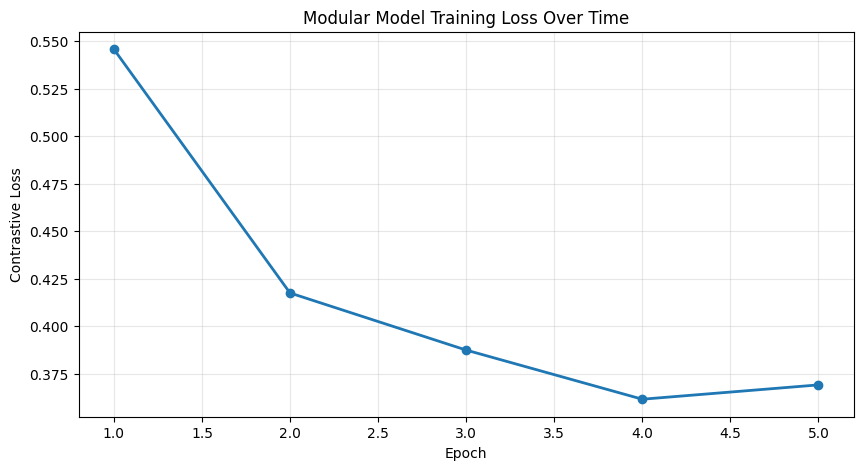


Final modular loss: 0.3691


In [38]:
# --- MODULAR HYBRID MODEL TRAINING (NO MANUAL ENCODER CREATION!) ---
# Force reload the module to pick up changes
import importlib
import modular_features

importlib.reload(modular_features)
from modular_features import (
    MetadataEncoderModular, HybridRouteModelModular
)
import torch.optim as optim
from tqdm.auto import tqdm

# Setup - Encoders are created AUTOMATICALLY from registry!
cnn_model = RouteCNN(embedding_dim=128)
metadata_encoder = MetadataEncoderModular(fusion_dim=128, embedding_dim=32)  # Auto-creates all registered encoders
modular_model = HybridRouteModelModular(cnn_model, metadata_encoder, fusion_dim=128).to(device)
criterion = ContrastiveLoss(margin=2.0)
optimizer = optim.Adam(modular_model.parameters(), lr=0.001)

print(f"🤖 Model created with {len(metadata_encoder.encoders)} feature encoders:")
for name in metadata_encoder.feature_names:
    print(f"   - {name}")

# Training function for modular model
def train_modular_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for (img1, features1), (img2, features2), labels in tqdm(dataloader, desc="Training Modular Model"):
        img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)
        
        # Move features to device
        features1 = {k: v.to(device) for k, v in features1.items()}
        features2 = {k: v.to(device) for k, v in features2.items()}
        
        optimizer.zero_grad()
        output1 = model(img1, features1)
        output2 = model(img2, features2)
        loss = criterion(output1, output2, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

# Train for a few epochs
num_epochs = 5
print(f"\n🚀 Starting modular training for {num_epochs} epochs...")
print("=" * 60)
modular_history = {'loss': []}
for epoch in range(num_epochs):
    avg_loss = train_modular_epoch(modular_model, hybrid_dataloader, criterion, optimizer, device)
    modular_history['loss'].append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")
print("\n✅ Modular training complete!")

# Plot training loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), modular_history['loss'], marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Contrastive Loss')
plt.title('Modular Model Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.show()
print(f"\nFinal modular loss: {modular_history['loss'][-1]:.4f}")


🔍 Finding similar routes using the modular hybrid model...

✅ Extracted embeddings for 1000 routes
   Features: ['overall', 'shape', 'metadata', 'pace', 'terrain', 'distance', 'time', 'runner_type']

🎯 Query route: #377


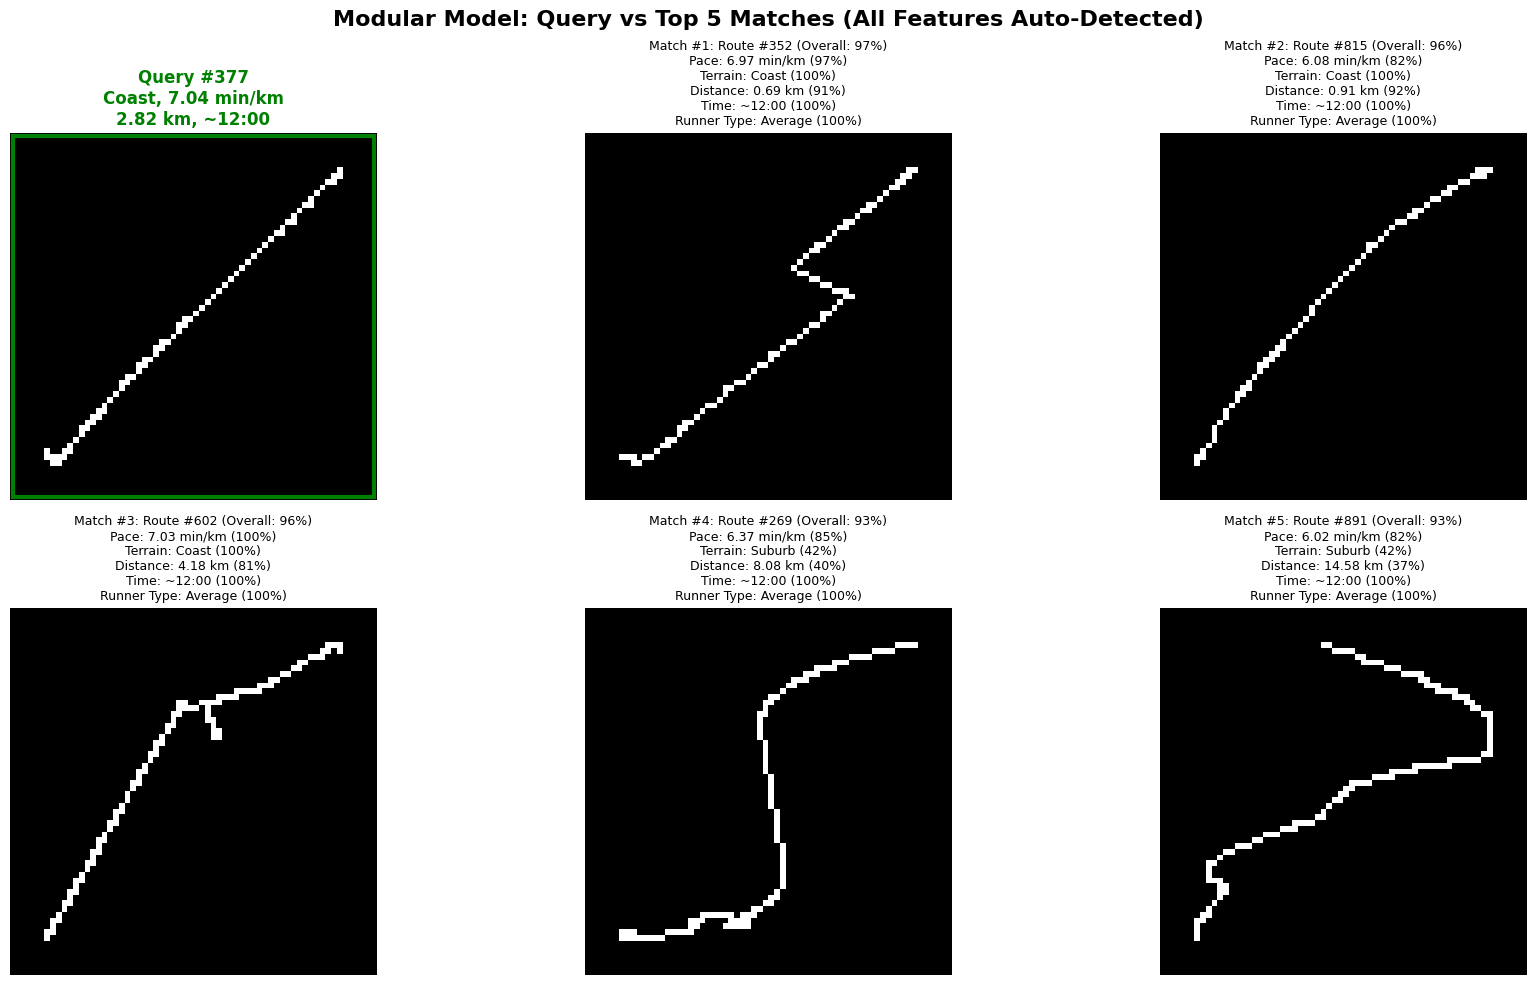


📊 Detailed Similarity Results:

🎯 QUERY Route #377:
   Terrain: Coast
   Pace: 7.04 min/km
   Distance: 2.82 km
   Time: ~12:00
   Runner Type: Average


1. Route #352 - Overall Similarity: 97.1%
   ├─ Shape:     94.1%
   ├─ Metadata:  96.9%
   ├─ Pace        :  97.1% → 6.97 min/km
   ├─ Terrain     : 100.0% → Coast
   ├─ Distance    :  91.1% → 0.69 km
   ├─ Time        : 100.0% → ~12:00
   └─ Runner Type : 100.0% → Average

2. Route #815 - Overall Similarity: 96.3%
   ├─ Shape:     95.8%
   ├─ Metadata:  93.8%
   ├─ Pace        :  82.1% → 6.08 min/km
   ├─ Terrain     : 100.0% → Coast
   ├─ Distance    :  91.6% → 0.91 km
   ├─ Time        : 100.0% → ~12:00
   └─ Runner Type : 100.0% → Average

3. Route #602 - Overall Similarity: 96.0%
   ├─ Shape:     91.1%
   ├─ Metadata:  92.2%
   ├─ Pace        :  99.5% → 7.03 min/km
   ├─ Terrain     : 100.0% → Coast
   ├─ Distance    :  80.7% → 4.18 km
   ├─ Time        : 100.0% → ~12:00
   └─ Runner Type : 100.0% → Average

4. Route #269 - Over

In [39]:
# --- MODULAR HYBRID MODEL: TEST & FEATURE SIMILARITY ---
import numpy as np
import matplotlib.pyplot as plt
import sys
import importlib

# Force reload to pick up latest changes
if 'modular_features' in sys.modules:
    del sys.modules['modular_features']

# Now import AFTER clearing cache
from modular_features import SimilarityCalculator, FeatureRegistry

print("🔍 Finding similar routes using the modular hybrid model...")

# Get embeddings for all routes (fused and individual features)
modular_model.eval()

# Initialize embeddings dict with all registered features
feature_names = list(FeatureRegistry.get_all_features().keys())
all_embeddings_dict = {
    'overall': [], 
    'shape': [], 
    'metadata': [],
    **{name: [] for name in feature_names}
}

with torch.no_grad():
    for i in range(len(hybrid_dataset.routes)):
        route_data = hybrid_dataset.routes[i]
        
        # Prepare image
        img = torch.FloatTensor(route_data['img']).unsqueeze(0).unsqueeze(0).to(device)
        
        # Extract features using registry (automatic!)
        features_raw = FeatureRegistry.extract_features(route_data['route_data'])
        features = {
            k: v.unsqueeze(0).to(device) 
            for k, v in FeatureRegistry.convert_to_tensors(features_raw).items()
        }
        
        # Get ALL embeddings (fused, cnn, metadata, individual features)
        fused, cnn_embed, metadata_embed, individual_embeds = modular_model(img, features, return_all=True)
        
        all_embeddings_dict['overall'].append(fused.cpu().numpy())
        all_embeddings_dict['shape'].append(cnn_embed.cpu().numpy())
        all_embeddings_dict['metadata'].append(metadata_embed.cpu().numpy())
        
        for feature_name, embed in individual_embeds.items():
            all_embeddings_dict[feature_name].append(embed.cpu().numpy())

# Convert to numpy arrays
for key in all_embeddings_dict:
    all_embeddings_dict[key] = np.vstack(all_embeddings_dict[key])

print(f"\n✅ Extracted embeddings for {len(hybrid_dataset.routes)} routes")
print(f"   Features: {list(all_embeddings_dict.keys())}")

# Calculate similarities
query_idx = np.random.randint(0, len(hybrid_dataset.routes))
print(f"\n🎯 Query route: #{query_idx}")

similarities = SimilarityCalculator.calculate_all_similarities(
    all_embeddings_dict, 
    query_idx, 
    include_self=False
)

# Get top 5 matches
most_similar_indices = np.argsort(similarities['overall'])[-5:][::-1]

# Helper function to format feature info
def format_feature_info(route_data):
    """Extract and format feature values for display"""
    route = route_data['route_data']
    features_raw = FeatureRegistry.extract_features(route)
    
    # Format based on feature type
    terrain = features_raw.get('terrain', 'unknown').title()
    pace = f"{features_raw.get('pace', 0):.2f} min/km"
    distance = f"{features_raw.get('distance', 0):.2f} km"
    time_hour = features_raw.get('time', 12.0)
    time_str = f"~{int(time_hour):02d}:00"
    runner_type = features_raw.get('runner_type', 'unknown').replace('_', ' ').title()
    
    return {
        'terrain': terrain,
        'pace': pace,
        'distance': distance,
        'time': time_str,
        'runner_type': runner_type
    }

# Visualize the query route and its 5 most similar matches
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

query_route = hybrid_dataset.routes[query_idx]
axes[0].imshow(query_route['img'], cmap='gray')
query_info = format_feature_info(query_route)
title_str = f"Query #{query_idx}\n{query_info['terrain']}, {query_info['pace']}\n{query_info['distance']}, {query_info['time']}"
axes[0].set_title(title_str, fontsize=12, fontweight='bold', color='green')
axes[0].axis('off')
axes[0].add_patch(plt.Rectangle((0, 0), 63, 63, fill=False, edgecolor='green', linewidth=3))

for i, similar_idx in enumerate(most_similar_indices, start=1):
    match_route = hybrid_dataset.routes[similar_idx]
    match_info = format_feature_info(match_route)
    
    axes[i].imshow(match_route['img'], cmap='gray')
    
    # Build title with similarity scores and actual values
    sim_overall = similarities['overall'][similar_idx]
    title_lines = [
        f'Match #{i}: Route #{similar_idx} (Overall: {sim_overall:.0f}%)'
    ]
    
    # Add feature similarities dynamically from registry
    for feat_name in feature_names:
        if feat_name in similarities and feat_name in match_info:
            title_lines.append(
                f"{feat_name.title().replace('_', ' ')}: {match_info[feat_name]} ({similarities[feat_name][similar_idx]:.0f}%)"
            )
    
    axes[i].set_title('\n'.join(title_lines), fontsize=9)
    axes[i].axis('off')

plt.suptitle('Modular Model: Query vs Top 5 Matches (All Features Auto-Detected)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n📊 Detailed Similarity Results:")
print("=" * 80)
print(f"\n🎯 QUERY Route #{query_idx}:")
for key, value in query_info.items():
    print(f"   {key.title().replace('_', ' ')}: {value}")
print("\n" + "=" * 80)

for rank, similar_idx in enumerate(most_similar_indices, start=1):
    match_route = hybrid_dataset.routes[similar_idx]
    match_info = format_feature_info(match_route)
    
    print(f"\n{rank}. Route #{similar_idx} - Overall Similarity: {similarities['overall'][similar_idx]:.1f}%")
    print(f"   ├─ Shape:    {similarities['shape'][similar_idx]:5.1f}%")
    print(f"   ├─ Metadata: {similarities['metadata'][similar_idx]:5.1f}%")
    
    for feat_name in feature_names:
        if feat_name in similarities:
            value_str = match_info.get(feat_name, 'N/A')
            symbol = "└─" if feat_name == feature_names[-1] else "├─"
            print(f"   {symbol} {feat_name.title().replace('_', ' '):12s}: {similarities[feat_name][similar_idx]:5.1f}% → {value_str}")

print("\n" + "=" * 80)
print("\n💡 To add a new feature: Just edit modular_features.py!")
print("   1. Create encoder class")
print("   2. Create extract_feature() function")
print("   3. Create feature_to_tensor() function")
print("   4. Register with FeatureRegistry.register()")
print("   5. Re-run this notebook - NO changes needed here!")


# 🚀 Export for Kotlin/Spring Boot Backend

Export pre-computed embeddings and metadata for deployment.

In [41]:
# --- EXPORT FOR KOTLIN BACKEND (ALL FEATURE EMBEDDINGS) ---
import numpy as np
import json
import os

# Create export directory
export_dir = "export_kotlin"
os.makedirs(export_dir, exist_ok=True)

# 1. Export ALL embeddings as binary (float32) - for per-feature similarity
print("📦 Exporting all feature embeddings...")

# Get all embedding types dynamically from all_embeddings_dict
embedding_types = list(all_embeddings_dict.keys())
print(f"   Found {len(embedding_types)} embedding types: {embedding_types}")

embeddings_info = {}
for emb_type in embedding_types:
    if emb_type in all_embeddings_dict:
        emb = all_embeddings_dict[emb_type].astype(np.float32)
        emb.tofile(f"{export_dir}/embeddings_{emb_type}.bin")
        embeddings_info[emb_type] = {
            'file': f"embeddings_{emb_type}.bin",
            'shape': list(emb.shape),
            'size_kb': round(emb.nbytes / 1024, 1)
        }
        print(f"   ✅ embeddings_{emb_type}.bin: {emb.shape} ({emb.nbytes / 1024:.1f} KB)")

# 2. Export route metadata as JSON
print("\n📋 Exporting route metadata...")

# Get feature names from registry
feature_names = list(FeatureRegistry.get_all_features().keys())

routes_metadata = []
for i, route_data in enumerate(hybrid_dataset.routes):
    route = route_data['route_data']
    features_raw = FeatureRegistry.extract_features(route)
    
    route_meta = {
        'index': i,
        'id': route.get('Filename', f'route_{i}'),
    }
    
    # Add all features dynamically
    for feat_name in feature_names:
        value = features_raw.get(feat_name, None)
        if isinstance(value, float):
            route_meta[feat_name] = round(value, 2)
        else:
            route_meta[feat_name] = value
    
    routes_metadata.append(route_meta)

metadata_json = {
    'count': len(routes_metadata),
    'embedding_dim': all_embeddings_dict['overall'].shape[1],
    'embedding_types': embedding_types,
    'feature_names': feature_names,
    'embeddings_info': embeddings_info,
    'routes': routes_metadata
}

with open(f"{export_dir}/routes.json", 'w') as f:
    json.dump(metadata_json, f, indent=2)
print(f"   ✅ routes.json: {len(routes_metadata)} routes with {len(feature_names)} features")

# 3. Save model state dict for future training/updates
print("\n💾 Saving model state...")
torch.save({
    'model_state_dict': modular_model.state_dict(),
    'embedding_dim': 128,
    'feature_names': feature_names,
}, f"{export_dir}/model.pt")
print(f"   ✅ model.pt saved")

# 4. Export feature encoding reference (for Kotlin to use same encoding)
from modular_features import TERRAIN_TYPES, RUNNER_TYPES, DAYS_OF_WEEK, TIME_OF_DAY_CATEGORIES

feature_encoding = {
    'terrain_classes': TERRAIN_TYPES,
    'runner_type_classes': RUNNER_TYPES,
    'days_of_week': DAYS_OF_WEEK,
    'time_of_day_categories': TIME_OF_DAY_CATEGORIES,
    'pace_normalization': 15.0,
    'distance_normalization': 50.0,
    'image_size': 64,
    'embedding_types': embedding_types,
    'feature_names': feature_names,
}

with open(f"{export_dir}/feature_encoding.json", 'w') as f:
    json.dump(feature_encoding, f, indent=2)
print(f"   ✅ feature_encoding.json saved")

print("\n" + "=" * 60)
print("🎉 EXPORT COMPLETE!")
print("=" * 60)
print(f"\n📁 Files in '{export_dir}/':")
total_size = 0
for f in sorted(os.listdir(export_dir)):
    size = os.path.getsize(f"{export_dir}/{f}")
    total_size += size
    print(f"   • {f}: {size / 1024:.1f} KB")

print(f"\n📊 Summary:")
print(f"   • Routes: {len(routes_metadata)}")
print(f"   • Features: {feature_names}")
print(f"   • Embedding types: {embedding_types}")
print(f"   • Total size: {total_size / 1024:.1f} KB")

print("\n🚀 Next: Copy these files to your Spring Boot resources folder!")
print("   cp -r export_kotlin/* your-spring-boot-app/src/main/resources/data/")

📦 Exporting all feature embeddings...
   Found 8 embedding types: ['overall', 'shape', 'metadata', 'pace', 'terrain', 'distance', 'time', 'runner_type']
   ✅ embeddings_overall.bin: (1000, 128) (500.0 KB)
   ✅ embeddings_shape.bin: (1000, 128) (500.0 KB)
   ✅ embeddings_metadata.bin: (1000, 128) (500.0 KB)
   ✅ embeddings_pace.bin: (1000, 32) (125.0 KB)
   ✅ embeddings_terrain.bin: (1000, 32) (125.0 KB)
   ✅ embeddings_distance.bin: (1000, 32) (125.0 KB)
   ✅ embeddings_time.bin: (1000, 32) (125.0 KB)
   ✅ embeddings_runner_type.bin: (1000, 32) (125.0 KB)

📋 Exporting route metadata...
   ✅ routes.json: 1000 routes with 5 features

💾 Saving model state...
   ✅ model.pt saved
   ✅ feature_encoding.json saved

🎉 EXPORT COMPLETE!

📁 Files in 'export_kotlin/':
   • embeddings.bin: 500.0 KB
   • embeddings_distance.bin: 125.0 KB
   • embeddings_metadata.bin: 500.0 KB
   • embeddings_overall.bin: 500.0 KB
   • embeddings_pace.bin: 125.0 KB
   • embeddings_runner_type.bin: 125.0 KB
   • embed